# [이론] 예측 평가와 교차 검증 — 지표 5개와 예측 원점

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 0. 오늘 배울 것

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">AI 데이터 인텔리전스 전문가 과정 · 시계열 예측</div>
<h1 style="color:#000000;margin:10px 0">예측을 채점하는 규칙 — 지표와 분할과 예측 기간</h1>
<div style="font-size:1.05em;color:#656565">어느 모형이 정말 나은지는 채점 규칙을 먼저 정한 뒤 판단합니다</div>
</div>

본문은 필수이고, 접힌 상자(「자세히」·「더 깊이」)는 선택입니다.

## 0. 오늘 배울 것

**AIC 가 낮은 셋째 날 SARIMA 가 검증 168시간의 RMSE 에서는 둘째 날 ARIMA 보다 크게 빗나갔습니다. 어느 모형이 나은지는 무엇으로 정할까요?**

셋째 날 오후 실습에서 서울 자전거 수요 모형 두 개, 둘째 날 ARIMA 와 셋째 날 SARIMA 를 비교했습니다.

두 모형이 예측하는 값은 하루 전 같은 시각과의 차이 $z_t = y_t - y_{t-24}$ 입니다. 이 계산을 **계절차분(seasonal differencing)** 이라 부릅니다. 11월 16일 23시에는 687대, 15일 23시에는 721대가 대여돼 $z_t = -34$대입니다. 이는 16일 23시 수요가 하루 전 같은 시각보다 34대 적다는 뜻입니다.

**둘째 날 ARIMA** 는 한 시간 전 $z$ 와 예측 오차(실측 − 예측)로 $z$ 를 예측합니다. **셋째 날 SARIMA** 는 여기에 하루 전 같은 시각의 $z$ 와 예측 오차를 더합니다(셋째 날 이론). 두 모형 모두 $z$ 를 예측한 뒤 하루 전 같은 시각의 실측을 더해 대여량으로 바꿉니다.

그러면 항을 더한 SARIMA 가 늘 더 나을까요? 학습 구간에서 한 시간 뒤 예측으로 재면 그렇습니다. 아래 표의 굵은 글씨는 행마다 더 작은 값입니다.

| 채점 | 무엇을 재나 | 둘째 날 ARIMA | 셋째 날 SARIMA |
|---|---|---:|---:|
| AIC | 학습 구간의 한 시간 뒤 오차가 작을수록, 계수가 적을수록 작다 | 25,209.34 | **24,502.69** |
| 검증 168시간을 한 번에 예측한 RMSE(대) | 오차를 제곱해 평균한 뒤 제곱근을 씌운 값 | **271.22** | 386.08 |

AIC 가 706.65 낮은 셋째 날 SARIMA 가 검증 168시간에서는 115대 더 빗나갔습니다. 이 과정의 운영은 금요일 23시에 다음 168시간의 배차용 예측을 한 번에 내는 일입니다. 그래서 168시간을 한 번에 예측할 때 어느 모형이 나은지는 AIC 로 정하지 않습니다.

어느 쪽이 정말 나은지는 이 한 주만 보고 답할 수 없습니다. 서울 공유자전거의 검증 구간은 1주일 전과 조건이 달랐습니다. 평균 기온이 4.91도로 1주일 전 9.37도보다 4.5도 낮았고, 시간당 평균 수요도 830.2대에서 694.2대로 줄었습니다. 그래서 여러 주에서 채점해 비교합니다.

학습 구간의 마지막 시각을 **예측 원점(forecast origin)** 이라 부릅니다. 예측 원점 5개(금요일 23시)를 두고, 원점마다 이어지는 한 주를 다시 채점해 RMSE 를 평균합니다.

후보는 두 모형에 계수를 추정하지 않는 규칙 둘을 더한 넷입니다.

**계절 나이브(seasonal naive)** 는 한 주기 전 같은 시각의 실제값을 그대로 예측값으로 쓰는 규칙입니다. 추정할 계수가 없어 누가 계산해도 같은 예측이 나옵니다. 이름 뒤의 수는 주기의 길이를 시간으로 적은 것입니다. 계절 나이브 24 는 하루 전 같은 시각, 계절 나이브 168 은 1주일(24 × 7 = 168시간) 전 같은 요일·같은 시각의 값을 씁니다.

| 11월 17일 토요일 8시 예측 | 가져오는 실제값 | 예측값 |
|---|---|---:|
| 계절 나이브 24 | 하루 전 11월 16일 금요일 8시 | 1,692대 |
| 계절 나이브 168 | 1주일 전 11월 10일 토요일 8시 | 589대 |

실제값은 530대였습니다. 토요일 8시는 금요일 8시보다 훨씬 적게 나가는데, 1주일 전 값을 쓰는 계절 나이브 168 만 같은 요일의 값을 가져옵니다.

| 후보 | 예측에 쓰는 값 | 주기 |
|---|---|---:|
| 둘째 날 ARIMA | 1시간 전 $z$ 와 예측 오차 | 24 |
| 셋째 날 SARIMA | 둘째 날 ARIMA 의 두 값에 하루 전 같은 시각 $z$ 와 예측 오차를 더함 | 24 |
| 계절 나이브 24 | 원점 직전 하루(11월 16일)의 값 24개를 7번 되풀이 | 24 |
| 계절 나이브 168 | 1주일 전 같은 시각의 값 | 168 |

계절 나이브 24 는 계수 없이 전날 값만 되풀이하는 규칙입니다. 전날 값을 쓰는 둘째 날 ARIMA 의 계수가 보태는 것이 있는지 보려고 후보에 둡니다. 11월 16일 원점 한 주에서는 둘이 271.22대와 271.23대로 거의 같았습니다.

네 후보는 같은 구간으로 학습하고 같은 구간에서 채점합니다. 테스트 구간은 채점 규칙과 후보를 모두 정한 뒤 마지막에 한 번만 엽니다.

| 구간 | 기간 | 길이 |
|---|---|---:|
| 전체 자료(서울 공유자전거 시간별 대여 수요) | 2017년 12월 ～ 2018년 11월 | 8,760시간 |
| 학습 구간 | 2018년 9월 1일 0시 ～ 11월 16일 23시(셋째 날 오후 실습과 같은 구간) | 1,848시간 |
| 검증 구간 | 11월 17일 ～ 23일 | 168시간 |
| 테스트 구간 | 11월 24일 ～ 30일 | 168시간 |

대여를 멈춘 휴무 295시간은 1주일 전 같은 시각 값으로 채웠습니다.

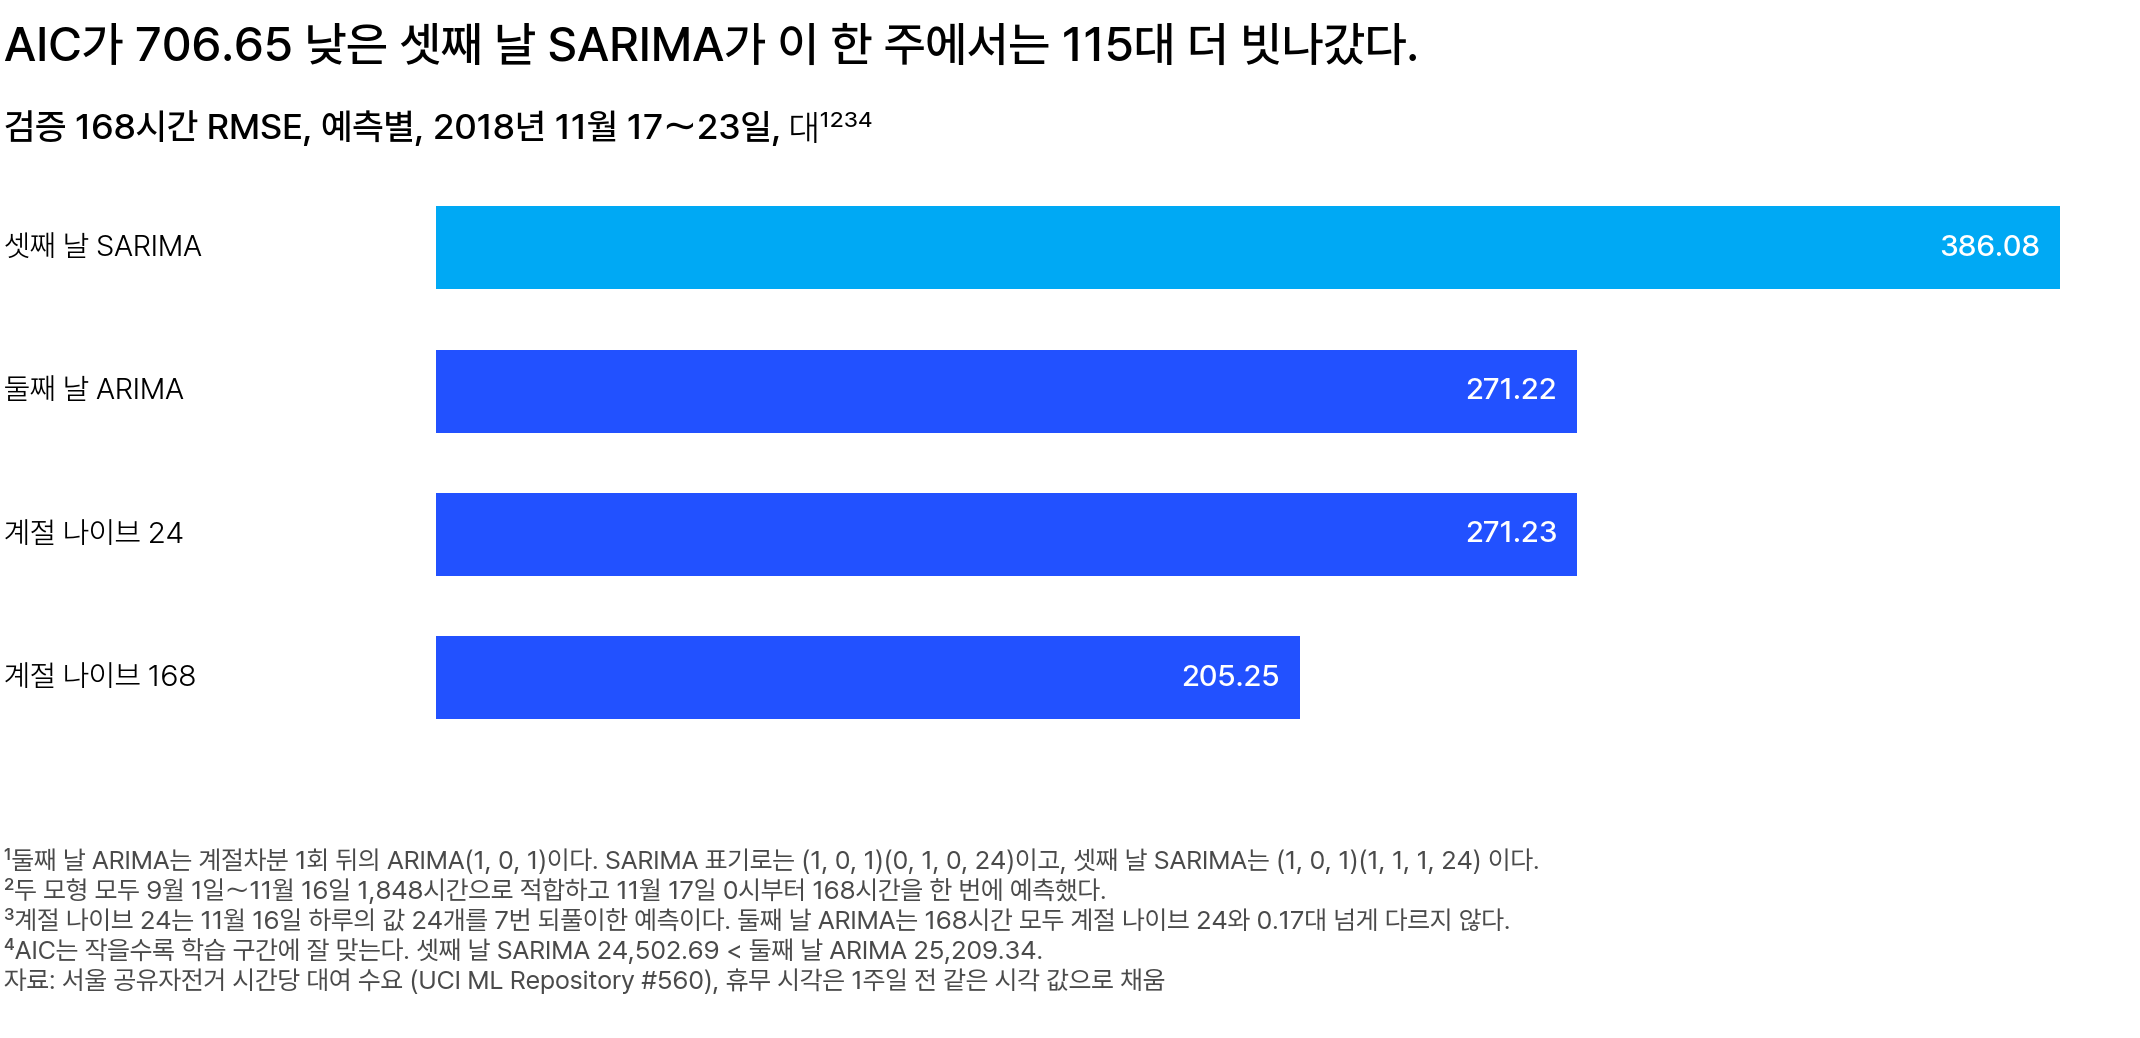

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 후보 4개가 검증 168시간에서 받은 RMSE. 하늘색 막대가 셋째 날 SARIMA 의 386.08 이고, 가장 짧은 막대는 계절 나이브 168 의 205.25 다. 두 모형의 AIC 는 각주에 적었다</em></p>

계절 나이브 168 이 두 모형보다 작게 빗나간 까닭은 요일에 있습니다. 두 모형은 1주일 전 값을 보지 않아 요일을 모릅니다.

앞 표의 11월 17일 토요일 8시에 둘째 날 ARIMA 는 하루 전 금요일 값을 거의 그대로 써 1,692.0대를 냈습니다. 실제는 530대라 1,162대 빗나갔습니다. 1주일 전 토요일 값(589대)을 쓴 계절 나이브 168 은 59대만 빗나갔습니다.

계수 없이도 이만큼 맞히는 규칙이라, 계절 나이브 168 을 모든 후보가 넘어야 할 기준으로 둡니다. 이 기준을 베이스라인(baseline)이라 부르고 모든 후보 옆에 적습니다.

**예측 기간(forecast horizon)** 은 원점에서 몇 시간 뒤까지 예측하는지를 적는 길이입니다. 검증 구간 168시간을 한 번에 예측하면 예측 기간은 168시간입니다.

지표·분할·예측 기간을 묶어 **평가 설계**라 부르고, 모형보다 먼저 정합니다. 규칙 없이 모형부터 만들면 지표값이 좋아진 것이 모형 덕인지 채점 조건이 쉬워진 덕인지 알 수 없기 때문입니다.

<div class="lms-summary">

**정리**

순위는 AIC 나 한 주 RMSE 로 정하지 않습니다. AIC 가 낮은 셋째 날 SARIMA 가 검증 168시간에서는 둘째 날 ARIMA 보다 더 빗나갔습니다. 계수가 없는 계절 나이브 168 이 205.25대로 가장 작았습니다.

**할 일**

- 계절 나이브 168 을 베이스라인으로 두고 모든 후보와 같은 표에 적습니다
- 테스트 구간(11월 24～30일)은 후보와 채점 규칙을 정한 뒤 한 번만 엽니다

평가 설계(지표·분할·예측 기간)를 먼저 정하고, 여러 주로 채점해서 순위를 정합니다.

</div>

## 1. 베이스라인과 채점 조건

**두 모형의 지표값을 나란히 비교해도 되는 조건은 무엇이고, 이 모듈은 어떤 조건으로 채점할까요?**

셋째 날에 계수를 하나도 추정하지 않는 규칙이 받은 지표값을 **베이스라인(baseline)** 이라 불렀습니다. 이 모듈의 베이스라인은 계절 나이브 168 입니다. 1주일 전 같은 요일·같은 시각의 실측을 그대로 예측으로 쓰므로, 하루 주기와 1주일 주기가 함께 들어갑니다. 검증 168시간 RMSE 는 맨 처음 막대그림에서 가장 짧은 막대인 205.25대입니다.

모형은 계수를 추정하는 수고를 들인 예측이라, 적어도 이 값보다 작게 빗나가야 쓸 까닭이 생깁니다.

### 학습 구간이 다르면 달라지는 지표값

11월 17일 하루만 채점하며 두 모형의 학습 구간만 바꾸면 이렇습니다. 굵은 글씨는 두 모형 가운데 행마다 더 작은 값입니다.

| 11월 17일 RMSE(대) | 둘째 날 ARIMA | 셋째 날 SARIMA | 계절 나이브 168(학습 없음) |
|---|---:|---:|---:|
| 11월 3～16일(336시간)로 학습 | 398.9 | **295.4** | 163.5 |
| 9월 1일～11월 16일(1,848시간)로 학습 | **399.3** | 447.1 | 163.5 |

학습 구간만 바꿨는데 더 작게 빗나간 모형이 행마다 다르고, 학습하지 않는 베이스라인만 두 행 모두 163.5대입니다. 하루만 채점한 값이라 어느 학습 길이가 낫다는 결론은 내리지 않습니다. 이 모듈은 9월 1일부터 원점까지로 학습하고, 지표값마다 학습 구간과 채점 구간을 함께 적습니다.

### 한 번에 예측할 때와 날마다 다시 예측할 때 지표값은 얼마나 다른가

- **168시간을 한 번에 예측**: 예측 원점에서 검증 구간 168시간을 한 번에 예측합니다. 마지막 시각은 마지막 실측에서 168시간 떨어져 있습니다.
- **날마다 다시 예측**: 하루가 지날 때마다 그날 실측 24개를 받아 다시 예측합니다. 계수는 다시 추정하지 않고 식에 들어가는 입력만 바뀝니다. 어느 시각도 마지막 실측에서 24시간 넘게 떨어지지 않습니다.

<img src="https://skforecast.org/latest/img/diagram-backtesting-no-refit.png" width="640" height="186"/>
<p align="center"><em>▲ 날마다 다시 예측하는 한 가지 구현. 맨 앞 구간으로 한 번 학습한 모형을 그대로 두고 예측만 순차로 갱신해, 회색 학습 구간은 분할마다 그대로이고 주황 채점 구간만 오른쪽으로 옮겨 간다. 초록은 이미 받은 실측이지만 계수 추정에는 다시 쓰지 않은 구간이고, 날마다 다시 예측할 때 식에 새로 들어가는 실측이 이 초록 구간에서 온다 (출처: skforecast, Backtesting)</em></p>

예측은 마지막 실측에서 멀수록 크게 빗나가므로, 규칙이 같다면 자주 다시 예측하는 쪽이 작은 RMSE 를 받습니다. 하루 전 같은 시각 값을 쓰는 계절 나이브 24 로 두 방식이 날마다 쓰는 값을 비교하면 이렇습니다. 괄호 안은 그날 8시 예측입니다.

| 예측할 날 | 8시 실측 | 168시간을 한 번에 예측: 원점 전날(16일) 같은 시각 값 | 날마다 다시 예측: 전날 실측 |
|---|---:|---|---|
| 17일 토 | 530 | 16일 금(1,692) | 16일 금(1,692) |
| 18일 일 | 371 | 16일 금 되풀이(1,692) | 17일 토(530) |
| 19일 월 | 1,751 | 16일 금 되풀이(1,692) | 18일 일(371) |
| 20～23일 화～금 | 1,516～1,818 | 16일 금 되풀이(1,692) | 19～22일 월～목(1,622～1,818) |
| 168시간 RMSE | | **271.23** | **245.45** |

날마다 다시 예측한 쪽이 대부분의 날에 덜 빗나갑니다. 다만 일요일 값을 쓰는 19일 월요일은 이쪽이 더 빗나갑니다. 자정마다 전날 실측으로 바꾸는 이 규칙을 **계절 나이브 24(자정마다 갱신)** 라 부릅니다.

날마다 다시 예측하는 쪽은 매일 새 실측을 받아 조건이 더 쉽습니다. 그래서 두 값의 차이는 모형 실력이 아니라 조건 차이이고, 순위표에서는 두 방식을 섞지 않습니다. 계절 나이브 24(자정마다 갱신)는 갱신 주기가 달라 후보가 아니고, 이 모듈의 순위에는 쓰지 않습니다.

채점 방식은 운영이 예측을 다시 내는 주기에 맞춥니다. 운영은 금요일 23시에 다음 168시간을 한 번에 예측하므로, 168시간을 한 번에 예측한 값으로 채점합니다.

<div class="lms-summary">

**정리**

지표값은 학습 구간·채점 구간·지표·예측 기간·갱신 주기가 같을 때만 나란히 읽습니다. 학습 구간만 바꿔도 11월 17일 하루의 두 모형 순위가 뒤바뀝니다. 같은 계절 나이브 24 도 자정마다 갱신하면 245.45대, 168시간을 한 번에 예측하면 271.23대입니다.

**할 일**

- 지표값마다 학습 구간·채점 구간·갱신 주기를 함께 적습니다
- 날마다 다시 예측한 값은 168시간을 한 번에 예측한 값과 같은 표에서 비교하지 않습니다

채점은 운영과 같이 금요일 23시에 168시간을 한 번에 예측한 값으로 합니다.

</div>

> **[문제] 베이스라인 205.25 쓰기**
>
> 205.25 는 계절 나이브 168 이 검증 구간에서 받은 RMSE 입니다. 1주일 전 같은 시각 값을 그대로 예측으로 쓴 규칙의 값이고, 둘째 날 ARIMA·셋째 날 SARIMA 의 값이 아닙니다. 이 숫자를 둘째 날 ARIMA·셋째 날 SARIMA 의 지표값과 함께 운영팀 보고서에 적는다면, 이 값을 무엇으로 소개하고 어떤 판단에 쓰자고 제안하겠습니까?

## 2. 오차를 한 숫자로 모으는 지표 5개

**지표(metric)** 는 시각마다 하나씩 나온 오차를 한 숫자로 모으는 계산 규칙입니다. 자주 쓰는 지표 MAE·RMSE·MAPE·SMAPE·MASE 5개는 모두 **오차(error)** 로 계산합니다.

$$
\underbrace{e_t}_{\text{시각 } t \text{ 의 오차}} = \underbrace{y_t}_{\text{실제값}} - \underbrace{\hat{y}_t}_{\text{예측값}}
$$

$e_t$ 가 양수면 모자라게(과소예측), 음수면 넘치게(과대예측) 예측한 것입니다.

11월 19일 월요일 8시에 계절 나이브 168 은 1주일 전 같은 시각의 1,699대를 예측했고 실제는 1,751대였으니 $e_t = 1{,}751 - 1{,}699 = 52$ 입니다.

부호를 그대로 둔 채 평균하면 +100 과 −100 이 서로 지워지므로, 지표 5개는 먼저 절댓값을 취하거나 제곱해 부호를 없앱니다. 그다음 오차를 무엇으로 나누느냐에 따라 세 묶음으로 나뉩니다.

| 묶음 | 지표 | 오차를 나누는 값 | 값의 단위 |
|---|---|---|---|
| 대수로 계산하는 지표 | MAE, RMSE | 나누지 않는다 | 대(자전거 대수) |
| 실제값으로 나눈 % 지표 | MAPE, SMAPE | 실제값이 들어간 분모 | % |
| 나이브 규칙 대비 배율 | MASE | 나이브 규칙이 학습 구간에서 받은 MAE | 배율(단위 없음) |

fpp3 는 Hyndman 과 Athanasopoulos 가 쓴 시계열 예측 교재의 약칭입니다. 원제는 『Forecasting: Principles and Practice』 3판이고, 약칭 뒤의 수는 목차 번호입니다. [fpp3 5.8 「점 예측 정확도 평가」](https://otexts.com/fpp3/accuracy.html)도 지표를 같은 세 묶음으로 나눕니다.

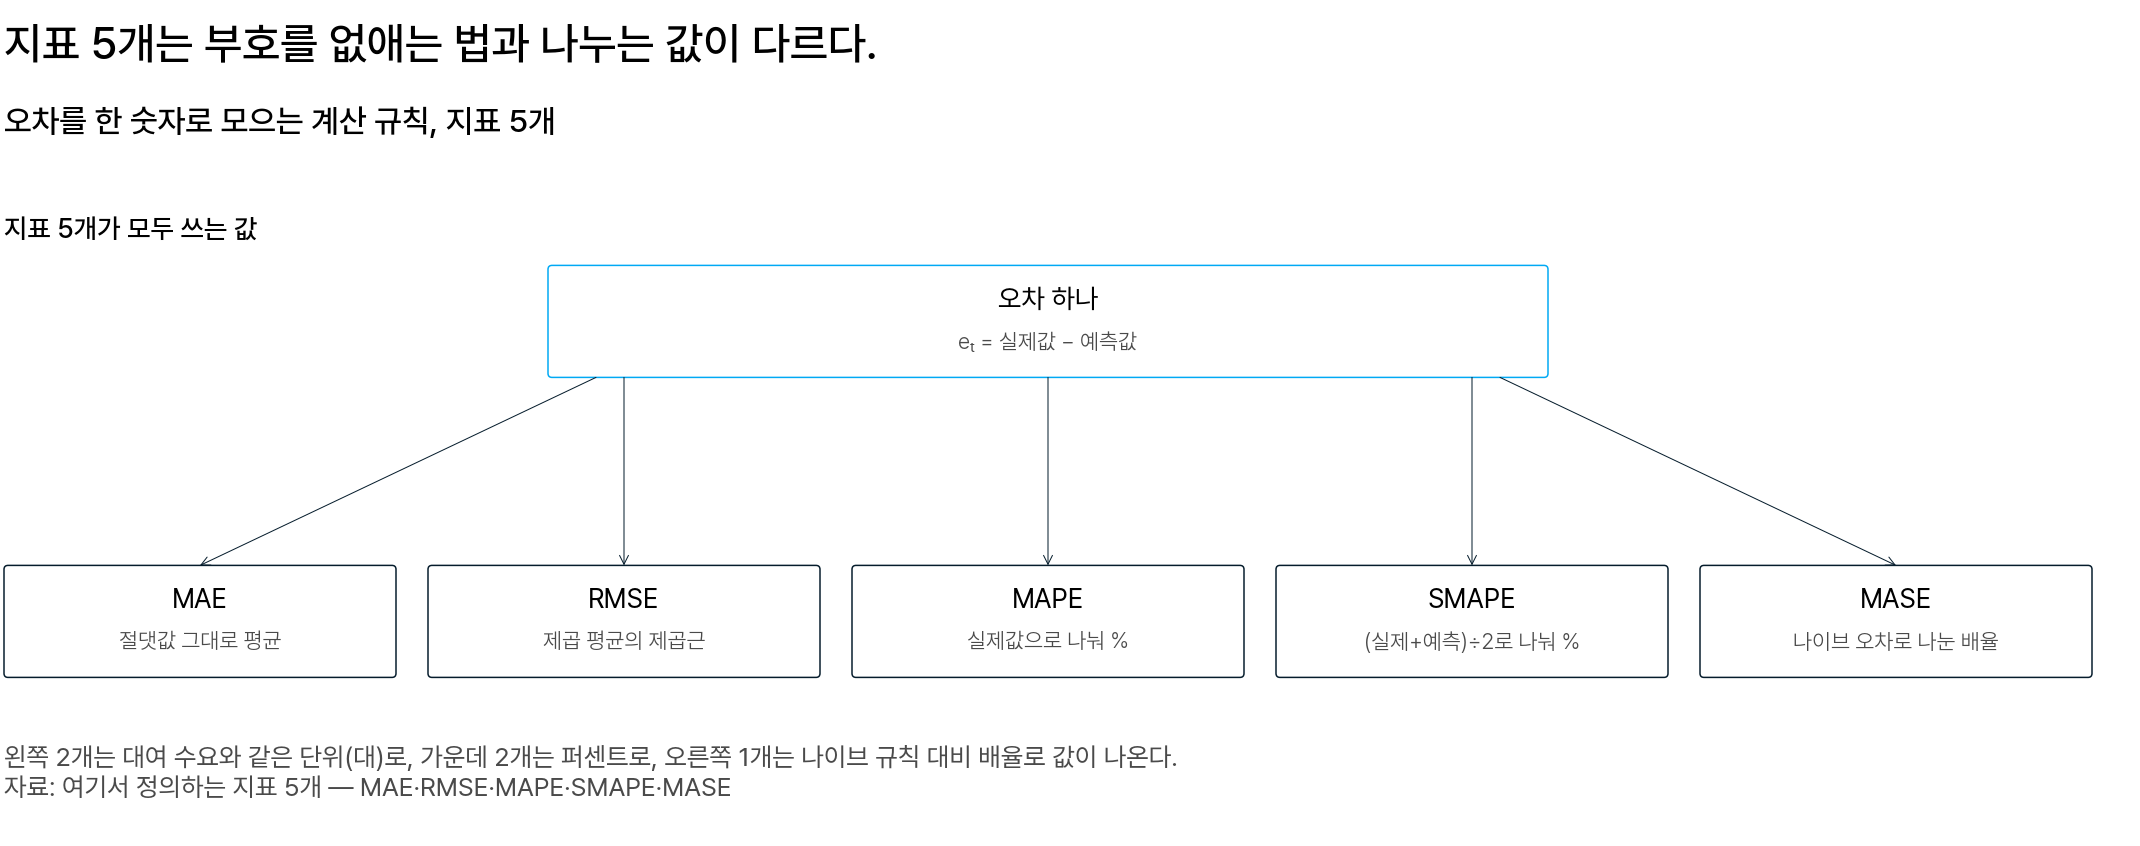

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 같은 오차 eₜ 로 계산하는 지표 5개. 위쪽 하늘색 상자가 지표 5개가 모두 쓰는 오차이고, 아래 상자 5개에 지표마다 그 오차로 하는 계산을 적었다</em></p>

## 시각 5개로 만든 계산 예시

| 시각 | 실제 $y_t$ | 예측 $\hat{y}_t$ | 오차 $e_t$ | $\lvert e_t\rvert$ | $e_t^{\,2}$ |
|---|---:|---:|---:|---:|---:|
| 1 | 2 | 12 | −10 | 10 | 100 |
| 2 | 100 | 92 | 8 | 8 | 64 |
| 3 | 50 | 58 | −8 | 8 | 64 |
| 4 | 80 | 74 | 6 | 6 | 36 |
| 5 | 120 | 132 | −12 | 12 | 144 |

1번 시각만 실제값이 2대로 유난히 작습니다. 아래 지표 5개를 모두 이 시각 5개로 계산합니다.

## MAE: 한 시각에 평균 몇 대 빗나갔나

셋째 날 본 **평균 절대 오차(mean absolute error, MAE)** 는 오차의 절댓값을 평균한 값입니다.

$$
\text{MAE} = \frac{1}{n}\sum_{t=1}^{n} |e_t|
$$

$n$ 은 채점하는 시각의 개수입니다.

MAE 가 150대라면 예측이 한 시각에 평균 150대씩 실제 수요에서 빗나갔다는 뜻입니다. 시각 5개 예시는 $|e_t|$ 10, 8, 8, 6, 12 의 합 44 를 5 로 나눠 MAE 8.80대이고, 한 시각에 평균 8.8대 빗나갔습니다.

- **좋은 점**: 모든 시각의 빗나간 대수를 같은 무게로 더합니다. 오차 6대인 4번 시각이 1대 더 빗나가도, 12대인 5번 시각이 1대 더 빗나가도 MAE 는 1 ÷ 5 = 0.2대 늘어납니다.
- **약한 점**: 크게 빗나간 한 번이 드러나지 않습니다. 오차가 0, 0, 0, 0, 44 로 한 시각에 몰려도 MAE 는 10, 8, 8, 6, 12 와 같은 8.80 입니다.
- **이럴 때 쓴다**: 손실이 모자란 대수에 비례할 때 MAE 로 순위를 정합니다. 배차(대여소마다 자전거를 미리 옮겨 두는 일)에서 100대 부족 열 번과 1,000대 부족 한 번을 같은 손실로 본다면 MAE 입니다. 서울 공유자전거에서는 RMSE 와 순위가 같은지 보려고 함께 계산합니다.

## RMSE: 큰 오차에 무게를 더 주면 몇 대 빗나갔나

셋째 날 본 **평균 제곱근 오차(root mean squared error, RMSE)** 는 오차를 제곱해 평균한 뒤 제곱근을 씌운 값입니다.

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{t=1}^{n} e_t^{\,2}}
$$

제곱하면 12대 오차가 6대 오차의 2배가 아니라 4배(144 와 36)로 들어갑니다.

RMSE 가 150대라면 큰 오차에 무게를 더 주어 잰 한 시각의 오차가 150대라는 뜻입니다. 단위는 MAE 와 같은 대이고, RMSE 는 MAE 보다 작아지지 않아 한 시각 평균 오차(MAE)는 150대 이하입니다. 오차의 크기가 모두 같으면 MAE 와 같고, 큰 오차가 섞일수록 MAE 보다 커집니다. 서울 공유자전거에서 계절 나이브 168 의 검증 구간 예측을 MAE 로 재면 158.76대, RMSE 로 재면 205.25대입니다. RMSE 가 약 46대 더 큰 것은 크게 빗나간 시각이 포함되어 있다는 뜻입니다. 시각 5개 예시는 $e_t^{\,2}$ 100, 64, 64, 36, 144 의 평균 81.6 에 제곱근을 씌운 RMSE 9.03대입니다. 다섯 오차가 6～12대로 크기가 비슷해서 MAE 와 거의 같습니다.

- **좋은 점**: 한 시각에 몰린 큰 오차가 값에 드러납니다. 오차 0, 0, 0, 0, 44 는 MAE 로는 8.80 그대로지만 RMSE 로는 19.68 로 2배 넘게 커집니다.
- **약한 점**: 좋은 점의 뒷면입니다. 큰 오차가 앞으로도 되풀이될 오차인지, 휴무나 기록 오류처럼 한 번뿐인 오차인지 RMSE 값만으로는 구별할 수 없습니다. 시각 5개 예시에서 5번 시각 오차만 12대에서 60대로 바꿔 봅니다. MAE 는 8.80 에서 18.40 으로 2.1배, RMSE 는 9.03 에서 27.80 으로 3.1배가 됩니다. 한 번뿐인 오차에도 RMSE 가 MAE 보다 더 끌려갑니다.
- **이럴 때 쓴다**: 크게 빗나간 한 번의 손실이 같은 대수의 작은 오차 여러 번보다 클 때 RMSE 로 순위를 정합니다. 서울 공유자전거에서는 후보의 순위를 RMSE 로 정합니다.

## MAPE: 실제 수요의 몇 % 만큼 빗나갔나

**평균 절대 백분율 오차(mean absolute percentage error, MAPE)** 는 백분율 오차의 평균입니다. 시각마다 오차를 그 시각의 실제값으로 나눠 백분율로 바꾼 뒤 평균합니다.

$$
\text{MAPE} = \frac{100}{n}\sum_{t=1}^{n} \frac{|e_t|}{|y_t|}
$$

MAPE 가 10% 라면 예측이 한 시각에 평균 실제 수요의 10% 만큼 빗나갔다는 뜻입니다. 한 시각의 백분율 오차를 **절대 백분율 오차(absolute percentage error, APE)** 라 부릅니다. 시각 5개 예시의 APE 는 이렇습니다.

| 시각 | 실제 $y_t$ | $\lvert e_t\rvert$ | APE = $\lvert e_t\rvert$ ÷ $y_t$ × 100 |
|---|---:|---:|---:|
| 1 | 2 | 10 | 500% |
| 2 | 100 | 8 | 8% |
| 3 | 50 | 8 | 16% |
| 4 | 80 | 6 | 7.5% |
| 5 | 120 | 12 | 10% |
| 합 | | | 541.5% |

5개를 평균한 MAPE 는 541.5 ÷ 5 = 108.3% 입니다.

- **좋은 점**: 실제 수요의 수준이 다른 계열끼리 비교할 수 있습니다. 평소 20대 나가는 대여소에서 10대 빗나가면 50%, 2,000대 나가는 대여소에서 10대 빗나가면 0.5% 입니다. MAE 로는 둘 다 10대라 보이지 않던 차이입니다.
- **약한 점**: 실제값이 0 에 가까운 시각 하나가 값을 크게 끌어올립니다. 시각 5개 예시의 MAPE 108.3% 가운데 100%p 가 실제값 2대인 1번 시각 하나에서 나옵니다. 실제값이 0 인 시각이 있으면 0 으로 나누게 되어 계산할 수 없습니다.
- **이럴 때 쓴다**: 실제값이 0 에서 먼 계열 여러 개를 단위나 수준과 상관없이 비교할 때 씁니다. 서울 공유자전거는 자정처럼 수요가 작은 시각이 있어 MAPE 하나로 결론을 내리지 않습니다.

### 왜 실제값이 작은 시각에서 MAPE 가 커지는가

1번 시각의 오차 10대는 다른 시각의 오차 6～12대와 크기가 비슷한데, APE 는 500% 입니다.

분모가 실제값이기 때문입니다. 오차를 2 로 고정하고 실제값만 바꾸면 이 관계가 곡선으로 보입니다.

> **[예측] 오차 크기를 2로 고정한 채 실제값만 바꿔 봅니다. 실제값이 2일 때와 8일 때의 APE는 어떻게 달라질까요?**
>
> 1. 오차가 같으니 둘 다 비슷하다
> 2. 실제값이 6 차이 나는 만큼 2 쪽이 조금 크다(약 1.3배)
> 3. 실제값 2 쪽이 100%, 8 쪽이 25%로 4배 차이가 난다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

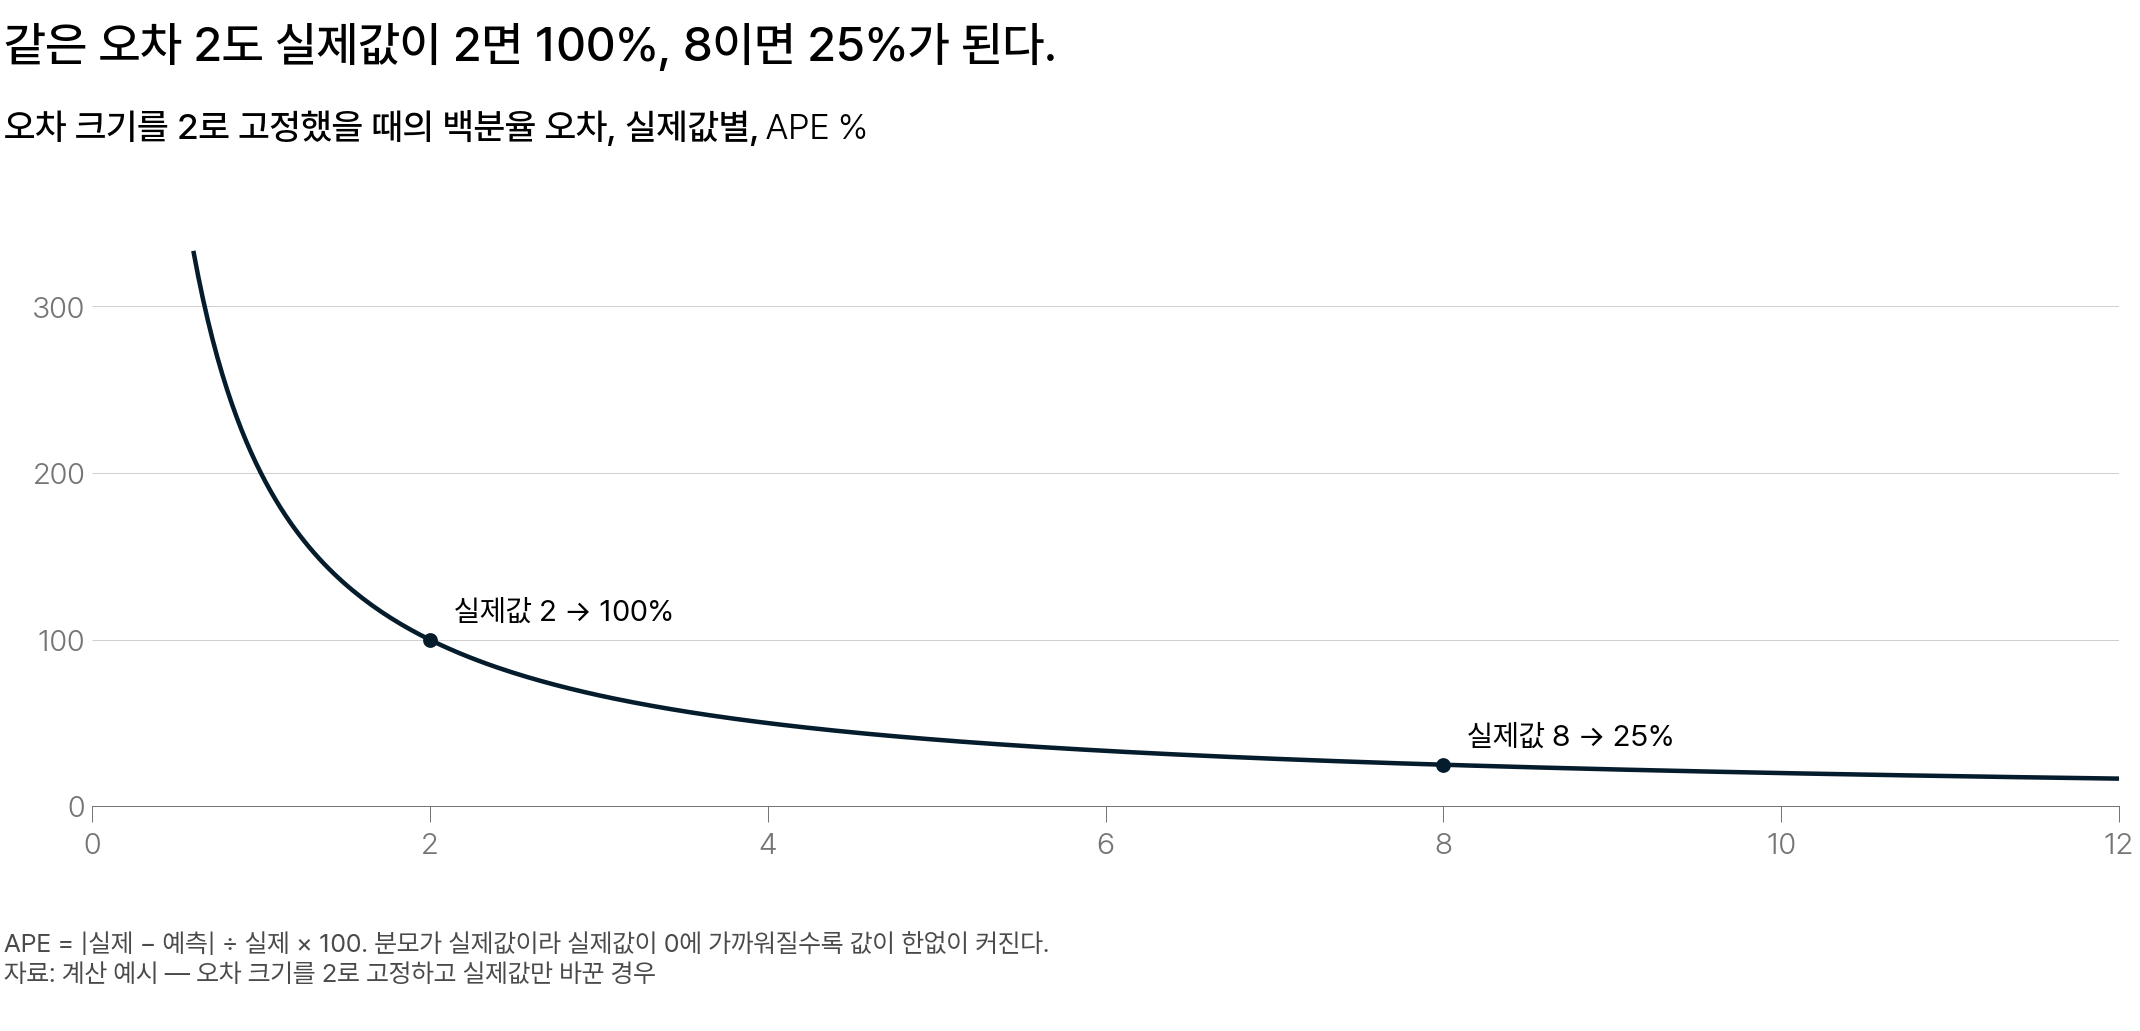

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 오차 크기를 2로 고정하고 실제값만 0.6～12 로 바꾼 곡선. 가로축이 실제값, 세로축이 APE(%)다. 틀린 양은 2로 똑같은데, 실제값이 작아지면 APE 가 급격히 커진다</em></p>

예상 질문의 답은 셋째 보기입니다. 실제값이 2 이면 APE 가 $2 \div 2 \times 100 = 100$%, 8 이면 $2 \div 8 \times 100 = 25$% 입니다. APE 는 실제값에 반비례해, 실제값이 0 에 다가가면 한없이 커집니다.

## SMAPE: 실제값과 예측값의 평균에 비해 몇 % 빗나갔나

**대칭 평균 절대 백분율 오차(symmetric MAPE, SMAPE)** 는 MAPE 의 분모를 실제값과 예측값의 평균 $(|y_t| + |\hat{y}_t|)/2$ 로 바꾼 지표입니다. 실제값 2대를 12대로 예측한 1번 시각은 MAPE 로 500% 지만, SMAPE 로는 분모가 7 이라 142.9% 입니다. 시각 5개 예시의 SMAPE 는 36.7% 입니다.

그러나 이름과 달리 대칭이 아닙니다. 실제값 100대를 110대로 넘치게 예측하면 9.5%, 90대로 모자라게 예측하면 10.5% 입니다. 넘치게 예측한 쪽이 유리하게 나오므로 서울 공유자전거 평가에는 쓰지 않습니다.

## MASE: 나이브 규칙의 오차보다 몇 배 빗나갔나

**평균 절대 스케일 오차(mean absolute scaled error, MASE)** 는 나이브 규칙 대비 배율입니다. 채점하는 모형의 MAE 를 나이브 규칙이 학습 구간에서 받은 MAE $Q$ 로 나눕니다. 나이브 규칙은 $m$ 시간 전 실제값을 그대로 예측으로 쓰는 규칙입니다. $m$ 은 계절이 없는 계열이면 1, 계절 주기가 있는 계열이면 그 주기입니다([fpp3 5.8](https://otexts.com/fpp3/accuracy.html)과 같은 규칙).

$$
\text{MASE} = \frac{\underbrace{\text{MAE}}_{\text{모형의 MAE}}}{\underbrace{Q}_{\text{나이브의 MAE}}}
$$

<img src="https://otexts.com/fpp3/fpp_files/figure-html/naive-method-explained-1.png" width="640" height="352"/>
<p align="center"><em>▲ 주기 m = 1 인 나이브 규칙. 마지막 관측값 하나(파란 점)를 미래 전체에 수평으로 이어서 예측으로 쓴다. 서울 공유자전거 MASE 의 분모는 m = 24 라 하루 전 같은 시각의 값을 쓴다 (출처: fpp3 §5.2, 호주 점토벽돌 생산)</em></p>

MASE 가 0.5 라면 모형의 MAE 가 $Q$ 의 절반이라는 뜻입니다. 시각 5개 예시에는 따로 떼어 둔 학습 구간이 없어, 직전 시각 값을 쓰는 나이브($m = 1$)를 같은 시각 5개에서 분모로 둡니다. 이웃한 실제값끼리의 차이 98, 50, 30, 40 의 평균이 $Q = 54.5$ 이고, MAE 8.80 을 $Q$ 로 나누면 MASE 0.161 입니다.

- **좋은 점**: 실제값으로 나누지 않아, 실제값이 0 인 시각이 있어도 수준이 다른 계열끼리 비교할 수 있습니다. 1번 시각 실제값을 0대로 바꾸면 MAPE 는 계산할 수 없지만 MASE 는 0.167 입니다.
- **약한 점**: 분모가 학습 구간의 오차라, 1 보다 작아도 같은 구간에서 나이브 규칙을 이겼다는 뜻은 아닙니다.

### 서울 공유자전거에서 MASE 의 분모

두 모형이 주기 24 로 계절차분하므로 분모도 $m = 24$ 로 맞춥니다. 그래서 $Q$ 는 하루 전 같은 시각의 실측을 예측으로 쓴 규칙의 학습 구간 MAE 입니다. 학습 1,848시간 가운데 하루 전 값이 있는 1,824시각(첫 24시간 제외)으로 평균합니다. 아래 코드로 $Q$ 를 직접 구해 봅니다.

In [ ]:
# MASE 의 분모 Q 를 학습 1,848시간에서 직접 구하기 — 매 시각 하루 전 같은 시각 실측을 예측으로 쓴 규칙의 MAE
import numpy as np
import pandas as pd

try:
    raw = load_csv("datasets/SeoulBikeData.csv")            # LMS 에서는 LMS 가 올려 둔 자료를 이 함수로 읽는다
except NameError:                                           # Colab·내 컴퓨터에는 이 함수가 없어 UCI 원본 주소에서 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
stamp = pd.to_datetime(raw["date"], format="%d/%m/%Y") + pd.to_timedelta(raw["hour"], unit="h")
cnt = pd.Series(raw["count"].astype(float).values, index=stamp).sort_index().asfreq("h")
off = pd.Series(raw["functioning"].eq("No").values, index=stamp).sort_index().asfreq("h")
bike = cnt.mask(off)
bike = bike.fillna(bike.shift(168)).fillna(bike.shift(-168))

train = bike.loc["2018-09-01 00:00":"2018-11-16 23:00"]      # 학습 1,848시간
gap24 = (train - train.shift(24)).abs().dropna()              # 하루 전 값이 있는 1,824시간
Q = gap24.mean()                                              # 하루 전 값이 빗나간 크기의 평균
t = "2018-09-10 08:00"
val = bike.loc["2018-11-17 00:00":"2018-11-23 23:00"]         # 검증 168시간
mae168 = (val - bike.shift(168)[val.index]).abs().mean()

print(f"MASE 의 분모 Q(하루 전 같은 시각 값을 예측으로 쓴 규칙의 학습 구간 MAE) = {Q:,.2f}대, 학습 {len(gap24):,}시각")
print(f"예: 9월 10일(월) 8시 실측 {train[t]:,.0f}대, 하루 전 같은 시각 {train.shift(24)[t]:,.0f}대라"
      f" 하루 전 값을 예측으로 쓰면 {gap24[t]:,.0f}대 빗나감")
print(f"계절 나이브 168 의 MASE: 검증 MAE {mae168:.2f}대 ÷ Q {Q:.2f}대 = {mae168 / Q:.2f}")

$Q$ = 295.40대는 학습 구간에서 하루 전 같은 시각 값이 평균 295.40대 빗나갔다는 뜻입니다. 이 값으로 나눈 검증 구간(11월 16일 예측 원점)의 MASE 는 이렇습니다.

| 예측 | 검증 168시간 MAE(대) | MASE = MAE ÷ 295.40 |
|---|---:|---:|
| 계절 나이브 168 | 158.76 | 0.54 |
| 둘째 날 ARIMA | 183.17 | 0.62 |
| 셋째 날 SARIMA | 301.60 | 1.02 |

셋째 날 SARIMA 의 1.02 는 검증 구간 MAE 가 $Q$ 보다 2% 크다는 뜻입니다. 분모를 만든 규칙을 자정마다 갱신해 검증 구간에 써도 MASE 는 1 이 아니라 0.47 입니다(갱신 주기가 달라 순위 비교용은 아님). 수요가 적은 검증 구간의 MAE 를 학습 구간의 $Q$ 로 나눴기 때문입니다.

그래서 MASE 는 두 가지에 씁니다. 대수로 적은 오차가 학습 구간의 전날 값 규칙보다 큰지 가늠할 때, 그리고 수준이 다른 계열 여러 개를 한 표에서 비교할 때입니다. 이 모듈의 순위는 RMSE 로 정합니다.

## 지표 5개 비교표

지표 5개에서 본 좋은 점·약한 점·쓰는 경우를 한 표로 모으면 이렇습니다.

| 지표 | 무엇을 재나 | 단위 | 좋은 점 | 약한 점 | 이럴 때 쓴다 |
|---|---|---|---|---|---|
| MAE | 한 시각에 평균 몇 대 빗나갔나 | 대(자전거 대수) | 모든 시각의 빗나간 대수를 같은 무게로 더한다 | 한 시각에 몰린 큰 오차가 드러나지 않는다 | 손실이 모자란 대수에 비례할 때 |
| RMSE | 큰 오차에 무게를 더 주면 몇 대 빗나갔나 | 대(자전거 대수) | 한 시각에 몰린 큰 오차가 값에 드러난다 | 다시 오지 않을 한 시각의 큰 오차에도 값이 크게 끌려간다 | 크게 빗나간 한 번이 작은 오차 여러 번보다 비쌀 때 |
| MAPE | 실제 수요의 몇 % 만큼 빗나갔나 | % | 실제 수요의 수준이 다른 계열끼리 비교할 수 있다 | 실제값이 0 에 가까운 시각에서 값이 크게 불어난다 | 실제값이 0 에서 먼 계열 여러 개를 비교할 때 |
| SMAPE | 실제값과 예측값의 평균에 비해 몇 % 빗나갔나 | % | 실제값이 작은 시각에서 MAPE 보다 덜 불어난다 | 같은 크기로 빗나가도 넘치게 예측한 쪽이 작게 나온다 | 보고 규정이 SMAPE 를 정해 둔 경우에만 |
| MASE | 나이브 규칙의 오차보다 몇 배 빗나갔나 | 배율(단위 없음) | 실제값이 0 인 시각이 있어도 수준이 다른 계열끼리 비교할 수 있다 | 1 보다 작아도 같은 구간에서 나이브 규칙을 이겼다는 뜻은 아니다 | 단위나 수준이 다른 여러 계열을 한 표에서 비교할 때 |

그래서 서울 공유자전거는 RMSE 로 순위를 정하고, MAPE·SMAPE 로는 결론을 내리지 않습니다. 백분율이 필요하면 오차 절댓값의 합을 실제값의 합으로 나눈 WAPE 로 적습니다.

## 5시각 예시에 지표 5개를 나란히 계산하기

아래 코드는 5시각 예시에 지표 5개를 나란히 계산합니다. 실제값 배열의 첫 원소 `2.0` 을 `20.0` 으로 바꿔 다시 실행해 보세요.

In [ ]:
# 지표 5개를 같은 오차 배열에 나란히 계산하기
import numpy as np

y = np.array([2.0, 100.0, 50.0, 80.0, 120.0])      # 실제값 — 첫 원소가 유난히 작다
yhat = np.array([12.0, 92.0, 58.0, 74.0, 132.0])   # 예측값
e = y - yhat                                        # 부호가 있는 오차

mae = np.mean(np.abs(e))
rmse = np.sqrt(np.mean(e ** 2))
mape = np.mean(np.abs(e) / y) * 100
smape = np.mean(2 * np.abs(e) / (np.abs(y) + np.abs(yhat))) * 100
# MASE 의 분모: 직전 시각의 실제값을 예측으로 쓴 나이브(m=1)의 MAE
# 이웃한 실제값끼리의 차이 98, 50, 30, 40 을 평균해 54.5 (시각 5개뿐이라 같은 5시각에서 구한다)
naive_mae = np.mean(np.abs(np.diff(y)))
mase = mae / naive_mae
ape = np.abs(e) / y * 100                          # 시각별 백분율 오차(APE)

print(f"같은 예측인데 MAPE {mape:.1f}%, MASE {mase:.3f}. MAPE 의 {ape[0] / ape.sum() * 100:.0f}% 가 "
      f"실제값 {y[0]:.0f}대인 첫 시각 하나에서 나온다")
print(f"MAE   {mae:8.2f}   (데이터와 같은 단위)")
print(f"RMSE  {rmse:8.2f}   (큰 오차를 크게 반영)")
print(f"MAPE  {mape:8.1f}%  (실제값으로 나눈 비율)")
print(f"SMAPE {smape:8.1f}%  (실제와 예측의 평균으로 나눈 비율)")
print(f"MASE  {mase:8.3f}   (나이브 오차 대비 배율)")

같은 예측이 MAPE 로는 108.3%, MASE 로는 0.161 입니다. MAPE 는 실제값 2대로 나눈 1번 시각의 APE 500% 에 끌려 커지고, MASE 는 나이브 오차 평균 54.5 로 나눠 작아집니다.

그래서 실제값이 작은 시각이 들어 있는 계열은 MAPE 하나로 판단하지 않습니다.

> **[문제] 앞에서 지표 5개를 나란히 계산한 코드는 실제값 `[2.0, 100, 50, 80, 120]` 과 예측값 `[12, 92, 58, 74, 132]` 를 씁니다. 실제값의 첫 원소 `2.0` 을 `20.0` 으로 바꿔 다시 실행하면, 아래 3개 가운데 값이 거의 그대로인 것은 무엇일까요?**
>
> 1. MAE
> 2. MAPE
> 3. SMAPE

### [직접 해보기] 같은 오차를 지표 5개로 계산하면 달라지는 값

위젯은 12시각의 가상 수요입니다. `실제값에 모두 60대 더하기` 는 12시각의 실제값에 같은 대수를 더하고, `4번 시각 오차 크기` 는 4번 시각의 오차만 3대에서 20대까지 키웁니다. 막대는 처음 값에 대한 배율이고, 1.00배에서 벗어난 막대만 하늘색입니다. 막대 아래 둘째 줄은 지표마다 오차를 나누는 값입니다.

1. **확인 질문.** `실제값에 모두 60대 더하기` 슬라이더만 30 까지 내리면 하늘색으로 바뀌는 막대는 무엇일까요?
   움직이기 전에 MAE·RMSE·MASE, MAPE·SMAPE, 지표 5개 모두 가운데 하나를 골라 두세요.
2. **해 보기.** 슬라이더는 한 번에 하나만 움직입니다. 먼저 `실제값에 모두 60대 더하기` 를 30 까지 내립니다. 다시 60 으로 맞춘 뒤, 이번에는 `4번 시각 오차 크기` 만 20 까지 키웁니다.
3. **관찰.** 하늘색으로 바뀐 막대와 그 아래 분모 줄, 오른쪽 `처음 값보다 가장 크게 달라진 지표` 를 함께 봅니다.

In [1]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/time-series/metric-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 실제값만 모두 내릴 때 하늘색으로 바뀌는 막대</summary>

**MAPE 와 SMAPE 두 막대만 1.51배로 커져 하늘색이 됩니다.** 두 막대 아래 분모 줄은 `÷ 실제값` 과 `÷ 실제값과 예측값의 평균` 입니다. 오차는 그대로인데 분모의 실제값이 작아져 비율이 커집니다.

MAE·RMSE 는 분모 줄이 `나누지 않음` 이라 1.00배 그대로입니다. MASE 의 분모 `÷ 나이브의 MAE` 는 이웃한 두 시각의 차이를 평균한 11.45대입니다. 12시각을 함께 낮춰도 이웃한 두 시각의 차이는 달라지지 않아 MASE 도 1.00배입니다.

</details>

<details class="lms-extra"><summary>더 해 보기 — 4번 시각 오차만 키울 때 가장 크게 커지는 지표</summary>

`실제값에 모두 60대 더하기` 를 60 에 둔 채 `4번 시각 오차 크기` 만 3 에서 20 까지 키우면 어느 지표가 가장 크게 커질까요? 위젯에서 확인한 뒤 아래를 읽습니다.

**RMSE 가 1.52배로 가장 크게 커집니다.** 오차를 제곱하기 때문입니다. MAE 는 늘어난 17대를 12 로 나눈 만큼만 커져 1.29배입니다.

MAPE 도 1.24배로 MAE 와 비슷하게만 오릅니다. 4번 시각의 실제값이 112대로 12시각 가운데 가장 커서, 그 시각의 APE 가 2.7% 에서 17.9% 로 오르는 데 그치기 때문입니다.

</details>

<div class="lms-summary">

**정리**

큰 오차 한 번이 비싸면 RMSE, 손실이 모자란 대수에 비례하면 MAE 로 순위를 정합니다. 실제값이 0 에 가까운 시각이 있으면 MAPE·SMAPE 로 결론을 내리지 않습니다. 시각 5개 예시의 MAPE 108.3% 가운데 100%p 가 실제값 2대인 한 시각에서 나옵니다. SMAPE 는 넘치게 예측한 쪽이 작게 나옵니다.

**할 일**

- 후보의 순위는 RMSE 로 정하고, 대수 오차의 크기를 가늠하려고 MASE 를 옆에 적습니다
- MASE 분모 $Q$ 는 학습 구간에서 하루 전 같은 시각 값이 빗나간 평균(295.40대)으로 계산하고, 보고서에 $m = 24$ 를 적습니다

지표는 어떤 오차를 크게 볼지에 따라 고릅니다.

</div>

> **[문제] MASE 0.64 옮기기**
>
> 검증 구간에서 어떤 모형의 MASE가 0.64로 나왔습니다. 이 숫자를 운영팀 보고서에 옮긴다면 어떤 한 문장이 될까요? 분모가 무엇인지, 1보다 작다는 것이 무슨 뜻인지가 문장에 들어가게 적어 보세요.

## 3. 서울 공유자전거 검증 구간의 지표값 — RMSE 를 대표 지표로 정하는 까닭

**서울 공유자전거에서 순위는 어떤 지표로 정하고, 백분율이 필요하면 무엇으로 적을까요?**

### 자정과 8시의 MAPE

> **[예측] 계절 나이브 168 로 검증 7일을 예측하고 MAPE를 시각별로 계산하면, 자정(0시)과 오전 8시 중 어느 쪽이 클까요?**
>
> 1. 그 시각 수요가 작아 분모가 작으니 자정 쪽이 크다
> 2. 출근 수요가 변덕스러워 예측이 어려우니 오전 8시 쪽이 크다
> 3. 같은 예측 방식이니 시각과 무관하게 둘이 비슷하다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

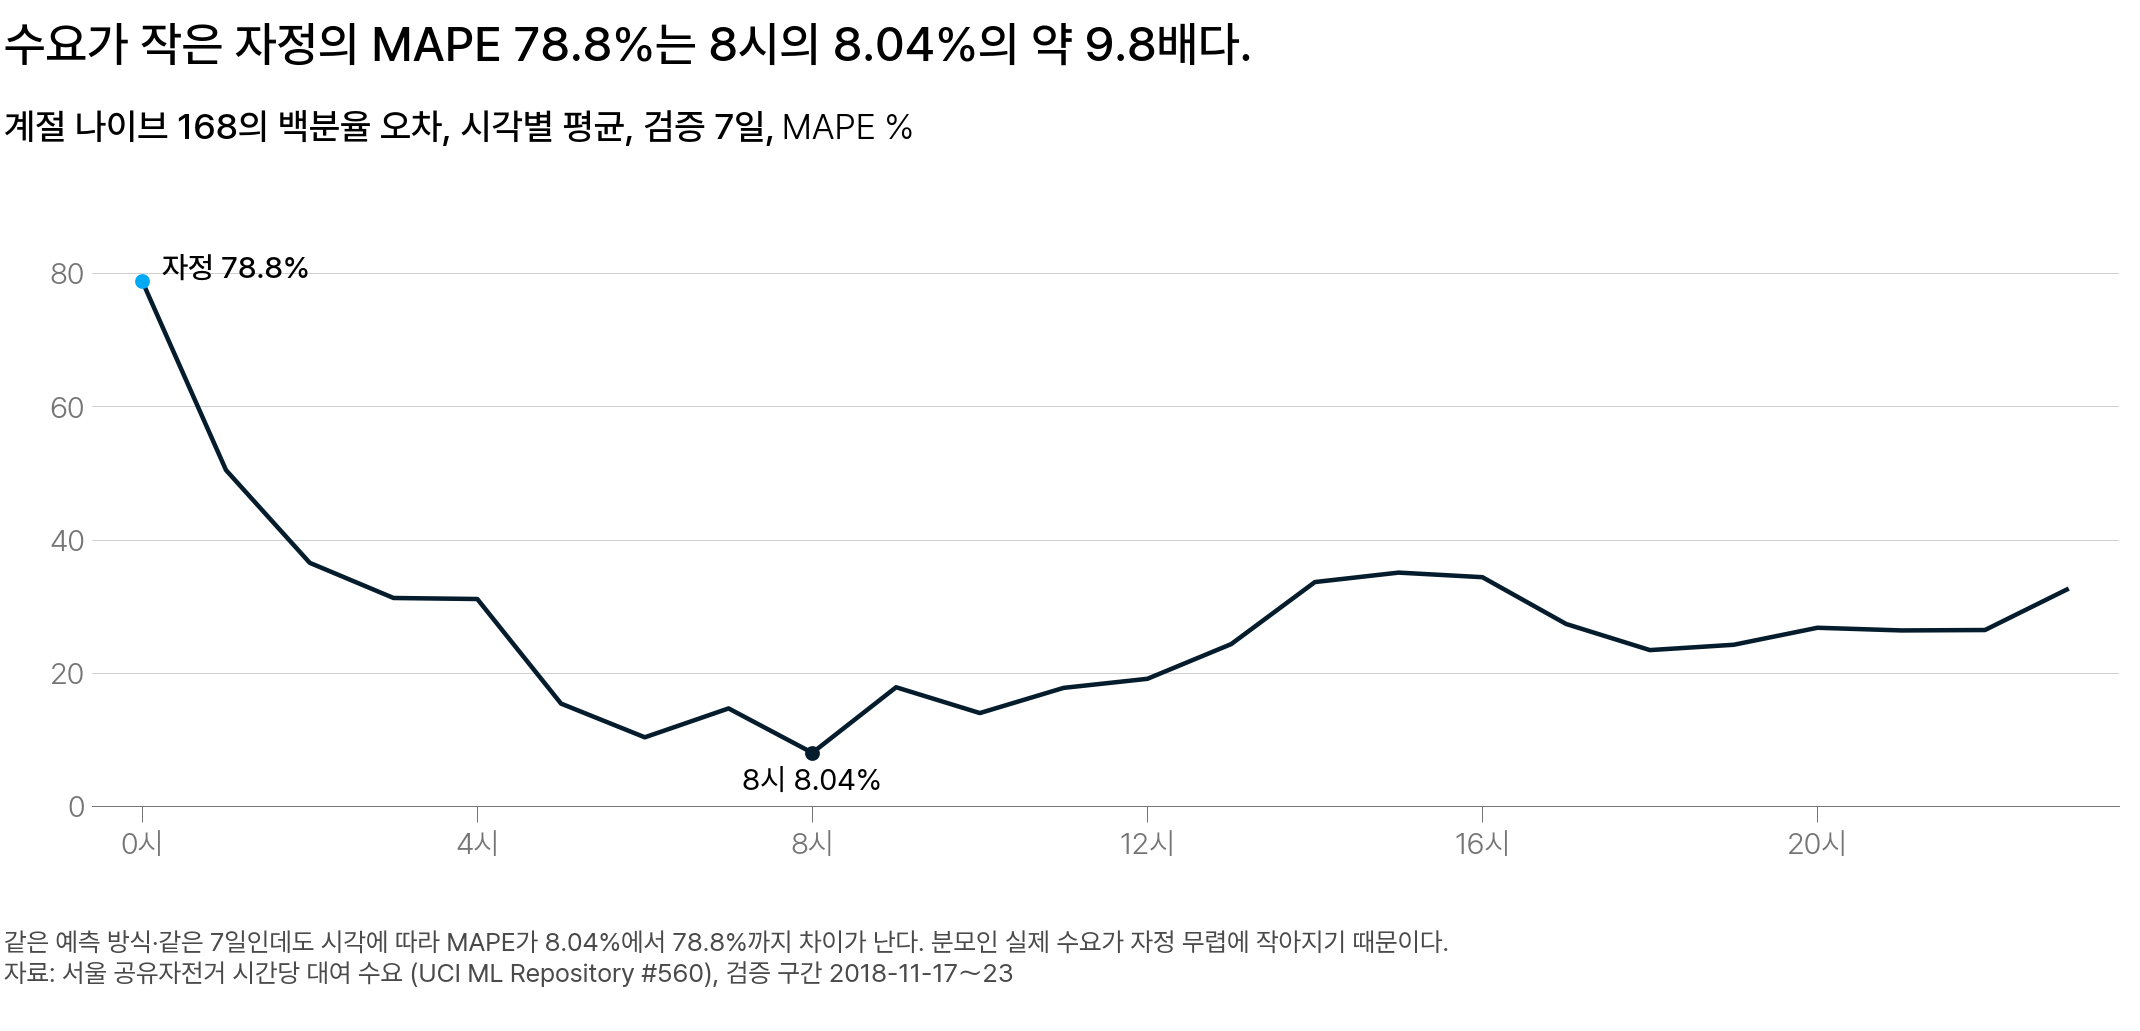

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 계절 나이브 168 의 시각별 평균 MAPE. 가로축은 하루 24시각, 세로축은 MAPE(%)다. 하늘색 점(자정) 78.8% 가 남색 점(8시) 8.04% 의 약 9.8배다</em></p>

예상 질문의 답은 첫째 보기입니다. 그러면 자정 예측이 8시 예측보다 9.8배 나쁜 것일까요? 아래 코드로 자정 7개 시각을 하나씩 계산해 봅니다.

In [ ]:
# ── 코드 4 · 검증 7일 자정 7개 시각의 APE 와 8시의 대수 오차
import numpy as np

days    = ["11-17", "11-18", "11-19", "11-20", "11-21", "11-22", "11-23"]
actual0 = np.array([626., 592., 457., 478., 119., 443., 470.])       # 검증 7일 자정의 실제 수요
snaive0 = np.array([754., 655., 456., 587., 612., 610., 683.])       # 168시간 전 값을 그대로 쓴 예측
actual8 = np.array([530., 371., 1751., 1818., 1622., 1671., 1516.])  # 같은 7일 오전 8시의 실제 수요
snaive8 = np.array([589., 395., 1699., 1910., 1916., 1686., 1692.])  # 같은 7일 오전 8시의 계절 나이브 168 예측

gap0, gap8 = np.abs(actual0 - snaive0), np.abs(actual8 - snaive8)   # 시각마다 빗나간 대수
ape0 = gap0 / actual0 * 100
assert round(ape0[4], 1) == 414.3 and round(ape0.mean(), 1) == 78.8   # 아래 표의 21일 자정 값과 7개 시각 평균

print(f"자정 MAPE {ape0.mean():.1f}% 가운데 {ape0[4] / len(ape0):.1f}%p 는 11월 {days[4][3:]}일 자정 한 시각"
      f"(실제 {actual0[4]:.0f}대, APE {ape0[4]:.1f}%)이 차지하는 부분")
print(f"7일 평균 오차: 자정 {gap0.mean():.1f}대, 8시 {gap8.mean():.1f}대 (자정이 {gap0.mean() / gap8.mean():.1f}배)")
print(f"7일 평균 수요: 자정 {actual0.mean():.1f}대, 8시 {actual8.mean():,.1f}대")
print(f"자정 WAPE (오차 합 ÷ 실제 수요 합): {gap0.sum():,.0f} ÷ {actual0.sum():,.0f} × 100 = "
      f"{gap0.sum() / actual0.sum() * 100:.1f}%")

| 날짜 | 실제 수요 | 계절 나이브 168 | 오차의 절댓값 | APE |
|---|---:|---:|---:|---:|
| 11월 17일 | 626대 | 754대 | 128대 | 20.4% |
| 11월 18일 | 592대 | 655대 | 63대 | 10.6% |
| 11월 19일 | 457대 | 456대 | 1대 | 0.2% |
| 11월 20일 | 478대 | 587대 | 109대 | 22.8% |
| **11월 21일** | **119대** | **612대** | **493대** | **414.3%** |
| 11월 22일 | 443대 | 610대 | 167대 | 37.7% |
| 11월 23일 | 470대 | 683대 | 213대 | 45.3% |
| **7개 시각 평균** | **455.0대** | | | **78.8%** |

서울 공유자전거에서 자정에 틀린 대수(7일 평균 오차)는 167.7대로 8시 101.7대의 1.6배입니다. 자정 수요가 작아 분모가 작은 것, 그리고 실제 수요가 119대로 떨어진 11월 21일 자정 한 시각이 1.6배를 9.8배로 키웁니다. 이 한 시각이 자정 MAPE 78.8% 가운데 59.2%p 를 차지합니다.

**그래서 시각별 MAPE 는 예측이 얼마나 나쁜지의 순위가 아닙니다.** 배차에서는 백분율이 아니라 모자란 대수, 곧 대수로 계산한 오차를 봅니다. 그래도 보고서에 백분율이 꼭 필요하다면 무엇을 적어야 할까요?

### WAPE: 오차 합이 실제 수요 합의 몇 % 인가

**가중 절대 백분율 오차(weighted absolute percentage error, WAPE)** 는 합끼리 나눈 백분율입니다. 시각마다 나누지 않고, 오차의 절댓값 합을 실제값 합으로 한 번 나눕니다.

$$
\text{WAPE} = 100 \times \frac{\sum_{t=1}^{n} |e_t|}{\sum_{t=1}^{n} |y_t|}
$$

분자와 분모를 모두 $n$ 으로 나누면 MAE 를 평균 실제값으로 나눈 값과 같습니다.

WAPE 가 10% 라면 빗나간 대수의 합이 실제 수요 합의 10% 라는 뜻입니다. 서울 공유자전거 자정 7개 시각은 오차 합 1,174대를 실제 수요 합 3,185대로 나눠 36.9% 입니다. 같은 7개 시각의 MAPE 78.8% 보다 작습니다.

- **좋은 점**: 실제값이 작은 시각 하나가 비율을 부풀리지 않습니다. 실제값 2대인 1번 시각은 시각 5개 예시의 MAPE 를 108.3% 로 끌어올렸습니다. WAPE 로는 오차 합 44대 ÷ 실제값 합 352대 × 100 = 12.5% 입니다.
- **약한 점**: MAE 를 평균 실제값으로 나눈 값이라, 큰 오차가 한 시각에 몰려도 드러나지 않습니다. 시각 5개 예시의 오차가 0, 0, 0, 0, 44 여도 WAPE 는 똑같이 12.5% 입니다.
- **이럴 때 쓴다**: 실제값이 작은 시각이 들어 있는 계열을 백분율로 보고해야 할 때 MAPE 대신 씁니다. 서울 공유자전거에서도 백분율은 WAPE 로 적습니다.

### RMSE 와 MAE 에서 가장 작은 예측이 바뀌는 까닭

계수를 추정하지 않는 예측 2개를 검증 168시간에서 채점합니다.

| 예측 | 예측으로 쓰는 값 | 실측을 받는 때 |
|---|---|---|
| **계절 나이브 24(자정마다 갱신)** | 하루 전 같은 시각의 값 | 자정마다 |
| **계절 나이브 168** | 1주일 전 같은 시각의 값 | 받지 않음(168시간을 한 번에 예측) |

두 예측은 실측을 받는 때가 달라 같은 조건이 아니므로, 이 대조로는 **지표에 따라 순서가 바뀌는지**만 봅니다.

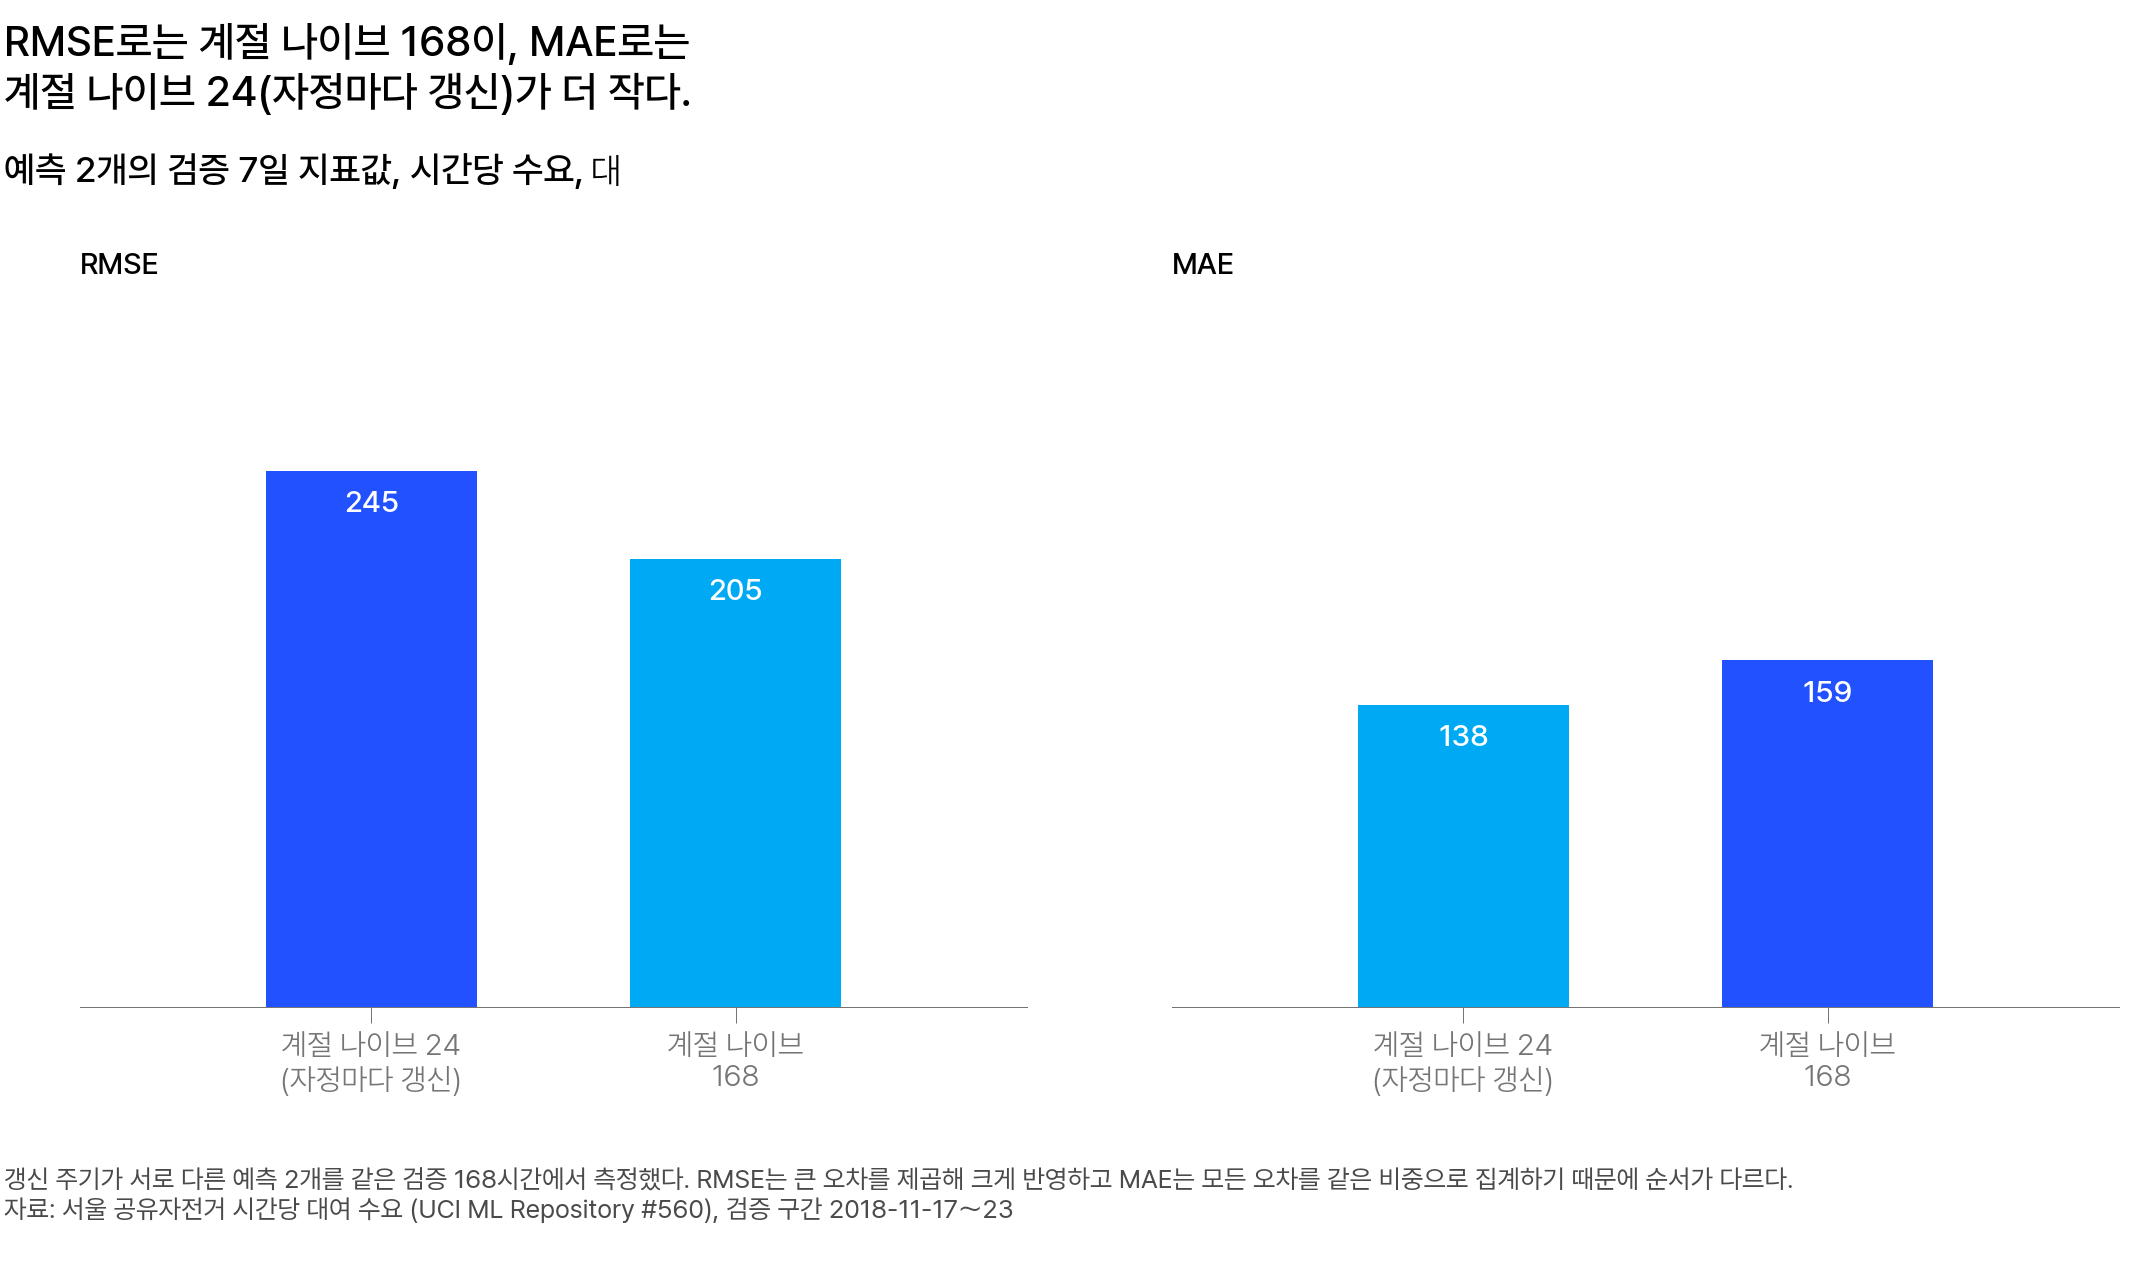

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 예측 2개의 검증 7일 지표값. 더 짧은 하늘색 막대가 왼쪽 RMSE 에서는 계절 나이브 168, 오른쪽 MAE 에서는 계절 나이브 24(자정마다 갱신)다</em></p>

MAE 로는 계절 나이브 24(자정마다 갱신)가 계절 나이브 168 보다 작은데, 왜 RMSE 로는 더 클까요?

이 규칙의 오차가 몇 시각에 몰려 있어서, 제곱하는 RMSE 만 크게 커지기 때문입니다. 4시각 오차로 예를 들면 이렇습니다.

| 예측 | 4시각 오차 | MAE | RMSE |
|---|---|---:|---:|
| A | 12 · 12 · 12 · 12 | 12 | 12 |
| B | 0 · 0 · 0 · 40 | 10 | 20 |

계절 나이브 24(자정마다 갱신)가 B 쪽입니다. 전날 값을 쓰므로 요일이 바뀌는 날에 크게 빗나갑니다.

| 8시 실제 수요 | 계절 나이브 24(자정마다 갱신, 전날 값) | 계절 나이브 168(1주일 전 값) |
|---|---|---|
| 11월 17일 토요일 530대 | 1,692대, 1,162대 빗나감 | 589대, 59대 빗나감 |
| 11월 19일 월요일 1,751대 | 371대, 1,380대 빗나감 | 1,699대, 52대 빗나감 |

이 규칙은 7일 제곱 오차 합의 84% 가 토요일·월요일 이틀에서 나옵니다. 작은 부족은 대여소에 남은 자전거로 메워도, 한 시각에 1,380대가 모자라면 다 메우지 못합니다. 그래서 서울 공유자전거에서는 이런 큰 오차 한 번을 크게 반영하는 RMSE 를 **대표 지표(primary metric)** 로 둡니다. 대표 지표는 결론을 내리는 지표 하나이고, 다른 지표에서 순서가 다르면 함께 적습니다.

<div class="lms-summary">

**정리**

대표 지표는 RMSE 로 두고, 백분율이 필요하면 MAPE 대신 WAPE 로 적습니다. 자정 MAPE 78.8% 가운데 59.2%p 는 실측 119대였던 11월 21일 자정 한 시각에서 나옵니다. 같은 7개 시각의 WAPE 는 36.9% 입니다.

**할 일**

- 후보의 순위는 RMSE 로 정하고, MAE 순위가 다르면 함께 적습니다
- 백분율은 오차 절댓값의 합을 실제값의 합으로 나눈 WAPE 로 적습니다

배차에서는 한 시각에 1,380대가 모자란 월요일 8시 같은 큰 오차가 가장 비쌉니다.

</div>

## 4. 시간 순서를 지킨 분할과 예측 원점 5개의 재채점

**시계열 모형을 채점할 때 자료를 어떻게 나눠야 할까요?**

필수 머신러닝에서 쓴 **K-겹 교차 검증(K-fold cross-validation)** 은 자료를 K개 **폴드(fold)** 로 나눕니다. 이름의 「겹」이 이 폴드입니다. 한 폴드씩 채점하고 나머지로 학습해 지표값을 평균합니다. 보통은 행 순서를 무작위로 섞은 뒤 K개로 나눕니다. scikit-learn 에서는 이 분할기를 `KFold(shuffle=True)` 로 만듭니다.

- **분할기(splitter)**: 분할마다 학습할 행과 채점할 행의 번호를 나눠 주는 scikit-learn 기능입니다.
- **`TimeSeriesSplit`**: 시간 순서를 지킨 분할기입니다. K-겹 교차 검증처럼 여러 번 채점하지만, 학습에는 **검증 폴드(validation fold)** 보다 앞선 시각만 씁니다. 검증 폴드는 한 분할에서 채점하는 부분이고, 학습에 쓰는 앞부분은 **학습 폴드(training fold)** 라 부릅니다.

9월 1일～11월 23일 2,016시간을 5번 분할합니다. 아래 코드는 11월 19일 월요일 8시(실측 1,751대)를 채점하는 분할이 무엇으로 학습했는지 보여 줍니다.

In [ ]:
# 11월 19일 월요일 8시 한 시각을 채점하는 분할에서 KFold(shuffle=True)와 TimeSeriesSplit 이 무엇으로 학습했나
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, TimeSeriesSplit

try:
    raw = load_csv("datasets/SeoulBikeData.csv")            # LMS 에서는 LMS 가 올려 둔 자료를 이 함수로 읽는다
except NameError:                                           # Colab·내 컴퓨터에는 이 함수가 없어 UCI 원본 주소에서 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw.index = pd.to_datetime(raw["date"], format="%d/%m/%Y") + pd.to_timedelta(raw["hour"], unit="h")
raw = raw.sort_index().asfreq("h")
cnt = raw["count"].astype(float).mask(raw["functioning"].eq("No"))
raw["bike"] = cnt.fillna(cnt.shift(168)).fillna(cnt.shift(-168))

span = raw.loc["2018-09-01 00:00":"2018-11-23 23:00"]            # 2,016시간
X = pd.get_dummies(pd.DataFrame({"hour": span.index.hour.astype(str),
                                 "dow": span.index.dayofweek.astype(str)}, index=span.index))
X["temp"], X["rain"] = span["temp"].values, span["rain"].values
X, yv = X.astype(float).values, span["bike"].values
k = span.index.get_loc(pd.Timestamp("2018-11-19 08:00"))        # 채점할 한 시각

seen, rounds, later8 = {}, {}, []
for name, splitter in [("KFold(shuffle=True)", KFold(5, shuffle=True, random_state=42)),
                       ("TimeSeriesSplit", TimeSeriesSplit(5))]:
    for r, (tr, te) in enumerate(splitter.split(X), start=1):
        if k in te:                                              # 이 시각을 채점하는 분할
            later = span.index[tr][span.index[tr] > span.index[k]]
            pred = LinearRegression().fit(X[tr], yv[tr]).predict(X[[k]])[0]
            seen[name], rounds[name] = (len(tr), len(later), round(pred, 1)), r
            if name == "KFold(shuffle=True)":
                later8 = [t for t in later if t.hour == 8]       # 학습에 든 뒤 시각 가운데 8시
assert seen == {"KFold(shuffle=True)": (1613, 94, 1212.4), "TimeSeriesSplit": (1680, 0, 1181.3)}, seen

print(f"결론: 11월 19일 8시를 채점하는 분할에서 KFold(shuffle=True)만 채점 시각보다 뒤 {seen['KFold(shuffle=True)'][1]}시간으로 학습했다")
for name, (n_train, n_later, _) in seen.items():
    print(f"{name} {rounds[name]}번째 분할: 학습 {n_train:,}시간 가운데 채점 시각보다 뒤 {n_later}시간")
print("KFold(shuffle=True) 학습에 든 뒤 시각의 8시:", ", ".join(f"{t:%m-%d} {span.loc[t, 'bike']:,.0f}대" for t in later8))

`KFold(shuffle=True)` 에서 11월 19일 월요일 8시를 채점하는 분할은 학습 1,613시간 가운데 94시간이 그 시각보다 뒤입니다. 운영이라면 월요일 아침에 화요일 실측은 아직 없습니다. 시계열은 오늘 값이 어제 값·지난주 같은 요일 값과 이어져 있어, 뒤 시각으로 학습하면 운영에서 할 수 없는 채점이 됩니다. 그래서 `KFold(shuffle=True)` 는 시계열 채점에 쓰지 않습니다.

순서를 섞지 않아도 문제는 남습니다. `KFold`(섞지 않음)는 행을 앞에서부터 차례로 K개 폴드로 나눕니다. 시점 20개인 계열을 `KFold(n_splits=4)`(검증 폴드 5시점)와 분할 4개인 `TimeSeriesSplit`(검증 폴드 4시점)으로 나누면 이렇습니다.

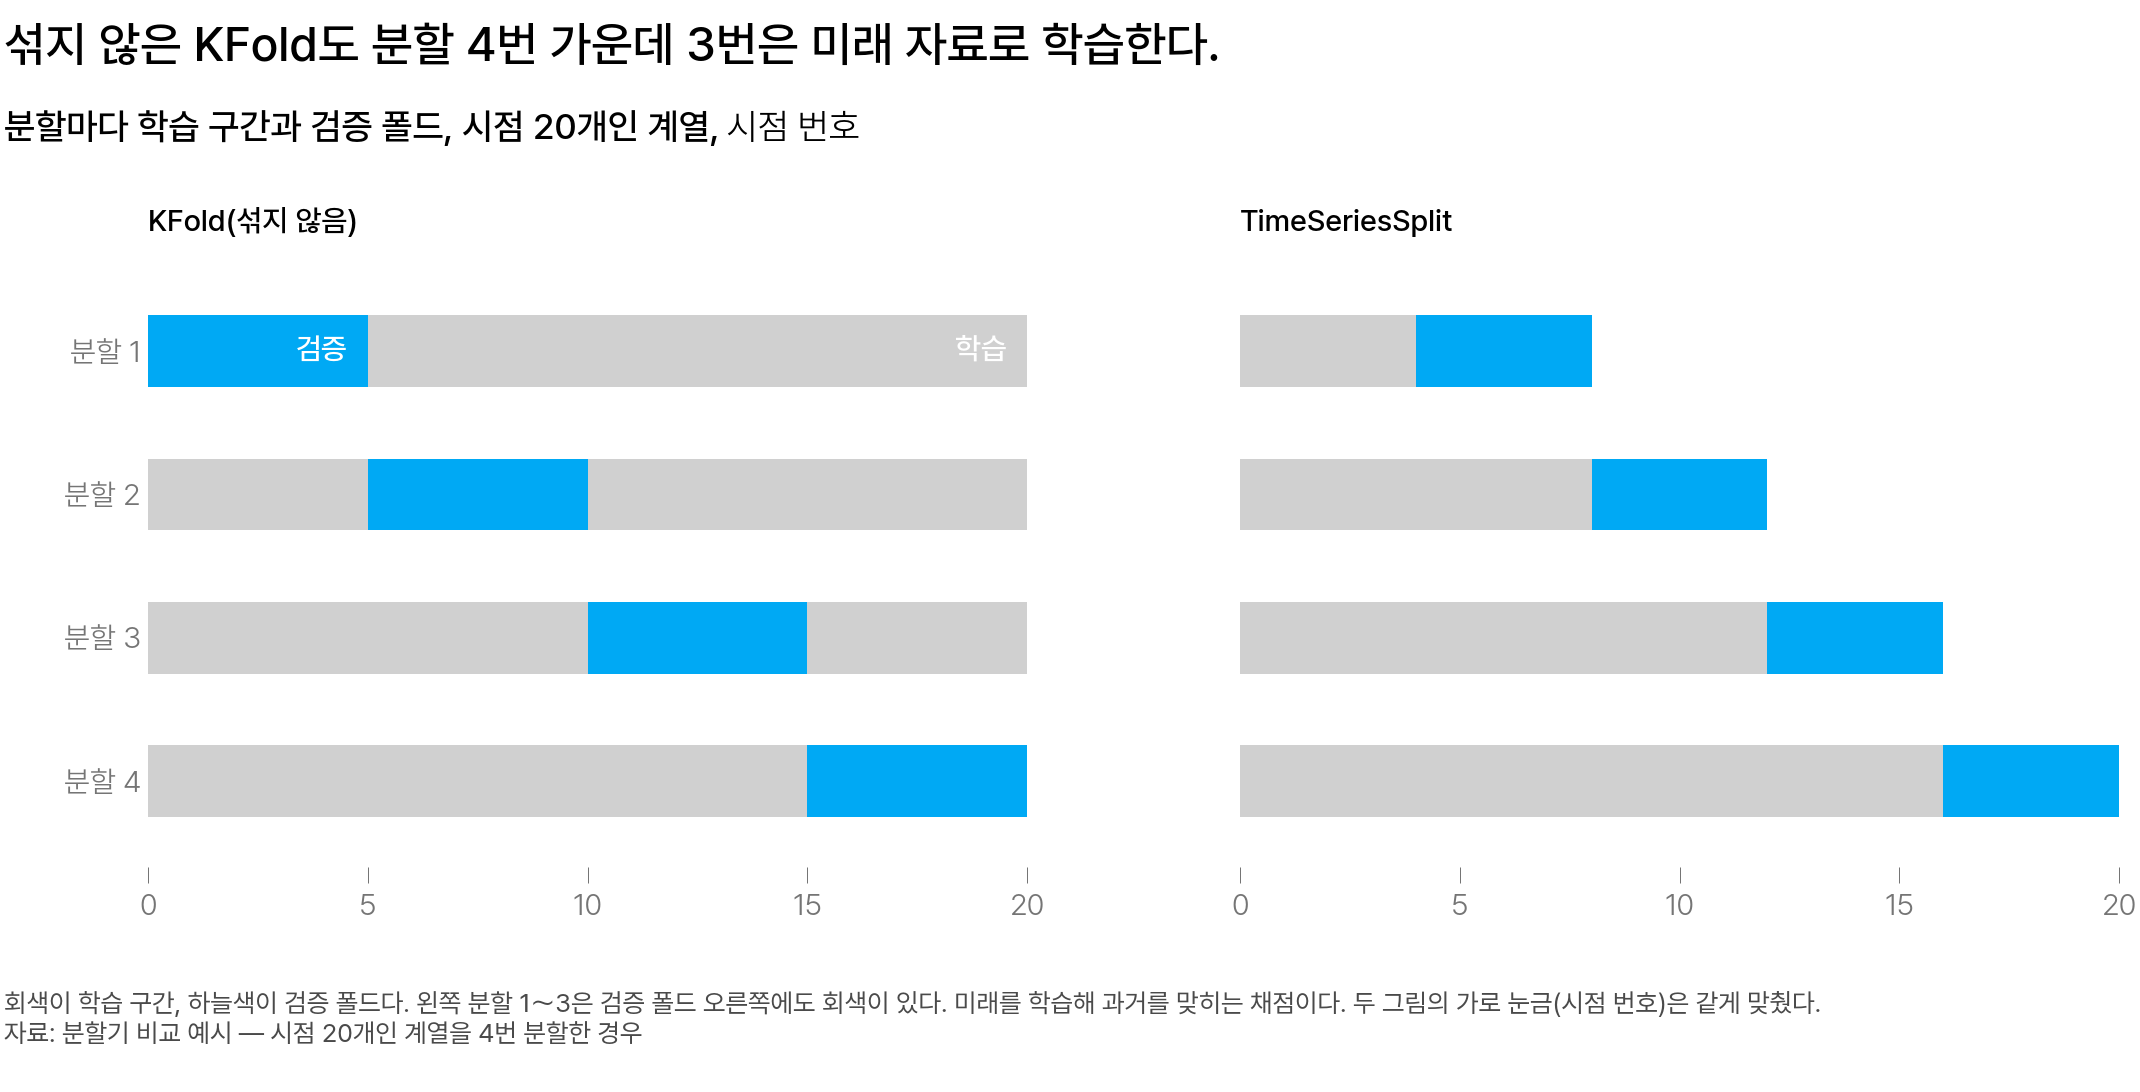

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 시점 20개인 계열을 4번 분할한 방식 2개. 가로축은 0 부터 센 시점 번호 0～20, 회색이 학습 구간·하늘색이 검증 폴드다</em></p>

- 왼쪽 `KFold`(섞지 않음): 분할 1 은 앞쪽 5개 시점을 채점하는데 학습 구간이 전부 그 뒤에 있습니다. 미래 자료로 학습한 분할이 4번 가운데 3번이고, 순서를 무작위로 섞으면 4번 모두입니다.
- 오른쪽 `TimeSeriesSplit`: 회색이 언제나 하늘색 왼쪽에만 있고 분할마다 길어집니다. 쓸 수 있는 과거가 늘어나는 운영과 같은 순서입니다.

그래서 섞지 않은 `KFold` 도 시계열 채점에는 쓰지 않고, 학습 구간이 늘 검증 폴드 왼쪽에 있는 `TimeSeriesSplit` 을 씁니다.

### 학습 구간과 검증 폴드 사이를 비우는 gap

금요일 23시까지의 실측으로 다음 주 월요일 0시부터의 배차를 정한다면, 토요일과 일요일 48시간의 실측은 예측할 때 없습니다. 이 빈칸을 채점에도 똑같이 두는 값이 `gap` 입니다.

`gap=48` 이면 학습 구간 끝 뒤 48시점을 건너뛰고 채점합니다. 학습 구간 끝 바로 다음 시각부터 168시간을 한 번에 예측하면 `gap` 이 0 입니다.

### [직접 해보기] 분할기가 바꾸는 학습 구간과 검증 폴드

학습 구간의 끝만 늘려 가는 방식은 **확장 윈도(expanding window)** 입니다. 학습 길이에 상한을 두고 통째로 옮기는 방식은 **롤링 윈도(rolling window)** 입니다. 위젯의 상한은 8시점입니다.

| 방식 | 특징 | 이런 경우에 쓴다 | 서울 공유자전거에서 |
|---|---|---|---|
| 확장 윈도 | 과거를 모두 학습에 쓴다. 한계: 앞 분할일수록 짧은 자료로 학습한다 | 자료가 짧아 덜어 낼 여유가 없을 때 | 예측 원점 5개 채점(학습 1,176～1,848시간) |
| 롤링 윈도 | 학습 길이가 고정된다. 한계: 상한보다 오래된 시각은 학습에서 빠진다 | 오래된 자료의 성질이 지금과 다를 때, 분할마다 학습 길이를 같게 맞출 때 | 쓰지 않는다 |

1. **확인 질문.** `KFold (섞지 않음)` 탭에서 분할 수가 6 이면 `검증 폴드보다 미래의 자료로 학습한 분할` 은 몇 개일까요?
   위젯을 보기 전에 0개, 3개, 5개 가운데 하나를 골라 두세요.
2. **해 보기.** 탭을 `KFold (섞지 않음)` → `TimeSeriesSplit (확장 윈도)` → `롤링 윈도 (학습 최대 8시점)` 순서로 누릅니다. 탭마다 `분할 수 n_splits` 를 4 에서 10 까지 움직이고, 뒤의 두 탭에서는 `gap` 슬라이더도 움직입니다.
3. **관찰.** 빗금 친 학습 구간(`검증보다 뒤 시점으로 학습`)이 어느 탭에 남는지, 오른쪽 아래 `검증 폴드보다 미래의 자료로 학습한 분할` 이 탭마다 어떻게 바뀌는지 봅니다. `KFold (섞지 않음)` 탭에서는 `gap` 슬라이더를 움직일 수 없고 `KFold 에는 gap 인자가 없습니다` 가 뜹니다.

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/time-series/cv-split-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — KFold 분할 수 6 에서 미래의 자료로 학습한 분할 수</summary>

**5개입니다.** 첫 화면인 `KFold (섞지 않음)` 탭에서 오른쪽 아래 값이 5 / 6개입니다. `KFold` 는 24시점을 4시점씩 폴드 6개로 나눠 하나씩 검증에 쓰고, 나머지를 모두 학습에 씁니다. 그래서 분할 1～5 는 검증 폴드 오른쪽에도 학습 구간이 남아 빗금으로 칠해집니다. 분할 6 만 검증 폴드가 계열 끝에 있어 그 뒤 시점이 없습니다.

분할 수를 바꿔도 빠지는 것은 마지막 분할 하나라, 미래의 자료로 학습한 분할은 늘 분할 수보다 1 적습니다(분할 수 4 에서 3개, 10 에서 9개). 나머지 두 탭에서는 학습 구간이 늘 검증 폴드 왼쪽에 있어 0개입니다. sklearn `KFold` 에는 `gap` 인자가 없어서, 위젯도 `KFold (섞지 않음)` 탭에서는 `gap` 슬라이더를 움직일 수 없게 해 두었습니다.

</details>

<details class="lms-extra"><summary>더 해 보기 — 분할 수를 4에서 10으로 늘릴 때 첫 분할의 학습 구간 길이</summary>

`TimeSeriesSplit (확장 윈도)` 탭에서 `gap` 을 0 에 둔 채 `분할 수 n_splits` 를 4 에서 10 으로 늘리면 첫 분할의 학습 구간은 길어질까요, 짧아질까요? 4 부터 1씩 키우며 오른쪽 아래 `첫 분할의 학습 구간 길이` 를 확인한 뒤 아래를 읽습니다.

**양 끝을 비교하면 짧아집니다.** 위젯의 시점 24개인 계열에서 분할 수 4 일 때 8시점이던 첫 분할의 학습 구간이 분할 수 10 에서는 4시점입니다. 1씩 키우면 8 → 4 → 6 → 3 → 8 → 6 → 4 로 오르내립니다. 검증 폴드 길이는 24 를 분할 수 + 1 로 나눠 소수점 아래를 버린 값입니다(분할 수 4 에서 4, 10 에서 2). 첫 분할의 학습 구간 길이는 24 − 분할 수 × 검증 폴드 길이입니다(분할 수 4: 24 − 4 × 4 = 8, 10: 24 − 10 × 2 = 4). 검증 폴드 길이가 소수점 아래를 버린 값이라, 분할 수를 1씩 키우면 남는 시점 수가 오르내립니다.

</details>

## `TimeSeriesSplit` 의 검증 폴드는 얼마로 두나

적합이 빠른 선형회귀 하나로 `TimeSeriesSplit` 의 설정을 바꿔 가며 채점합니다. 설명 변수는 시각 더미 24개와 요일 더미 7개에 기온·강수를 더한 것이고, 더미는 그 시각이면 1, 아니면 0 을 적는 열입니다.

In [ ]:
# 같은 선형회귀를 분할기 4개로 5번씩 채점하기 — 위 코드와 같은 자료·설명 변수, 9월 1일～11월 23일 2,016시간
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, TimeSeriesSplit

try:
    raw = load_csv("datasets/SeoulBikeData.csv")            # LMS 에서는 LMS 가 올려 둔 자료를 이 함수로 읽는다
except NameError:                                           # Colab·내 컴퓨터에는 이 함수가 없어 UCI 원본 주소에서 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
raw.index = pd.to_datetime(raw["date"], format="%d/%m/%Y") + pd.to_timedelta(raw["hour"], unit="h")
raw = raw.sort_index().asfreq("h")
cnt = raw["count"].astype(float).mask(raw["functioning"].eq("No"))
raw["bike"] = cnt.fillna(cnt.shift(168)).fillna(cnt.shift(-168))

span = raw.loc["2018-09-01 00:00":"2018-11-23 23:00"]            # 2,016시간
X = pd.get_dummies(pd.DataFrame({"hour": span.index.hour.astype(str),
                                 "dow": span.index.dayofweek.astype(str)}, index=span.index))
X["temp"], X["rain"] = span["temp"].values, span["rain"].values
X, yv = X.astype(float).values, span["bike"].values

splitters = {"KFold(shuffle=True)": KFold(5, shuffle=True, random_state=42),
             "KFold(섞지 않음)": KFold(5),
             "TimeSeriesSplit": TimeSeriesSplit(5),
             "TimeSeriesSplit(test_size=168)": TimeSeriesSplit(5, test_size=168)}
pred_by, mean_rmse, first, lines = {}, {}, {}, []
for name, splitter in splitters.items():
    pred, rmses = np.full(len(yv), np.nan), []
    for tr, te in splitter.split(X):
        pred[te] = LinearRegression().fit(X[tr], yv[tr]).predict(X[te])
        rmses.append(np.sqrt(np.mean((yv[te] - pred[te]) ** 2)))
        first.setdefault(name, (span.index[tr][0], span.index[tr][-1], rmses[0]))   # 첫 분할의 학습 구간과 RMSE
    pred_by[name], mean_rmse[name] = pred, round(float(np.mean(rmses)), 2)
    scored = span.index[~np.isnan(pred)]                         # 한 번이라도 채점한 시각
    lines.append(f"{name}: 채점 {len(scored):,}시간({scored[0]:%m-%d}부터) · 평균 RMSE {mean_rmse[name]:.2f}대")

weeks = np.arange(len(yv) - 840, len(yv)).reshape(5, 168)       # 10월 20일부터 5주, 주마다 168시간
shuf = pred_by["KFold(shuffle=True)"]
weekly = [np.sqrt(np.mean((yv[w] - shuf[w]) ** 2)) for w in weeks]
nov = span.index >= "2018-11-01"

print(f"결론: 검증 폴드를 168시간으로 맞춘 TimeSeriesSplit 의 평균 RMSE "
      f"{mean_rmse['TimeSeriesSplit(test_size=168)']:.2f}대. "
      f"KFold(shuffle=True) 는 뒤 시각으로 학습해 쓰지 않는다")
print("\n".join(lines))
t0, t1, r1 = first["TimeSeriesSplit"]
print(f"기본 TimeSeriesSplit 첫 분할({t0:%m-%d}～{t1:%m-%d} 학습) RMSE {r1:.1f}대")
print(f"11월 1～23일 실측 평균 {yv[nov].mean():.1f}대 · 평균 예측: KFold(shuffle=True) {shuf[nov].mean():.1f}대, "
      f"TimeSeriesSplit {pred_by['TimeSeriesSplit'][nov].mean():.1f}대")
assert list(mean_rmse.values()) == [355.50, 375.18, 399.25, 335.67], mean_rmse
assert round(float(np.mean(weekly)), 2) == 307.62
assert [round(float(v[nov].mean()), 1) for v in (yv, shuf, pred_by["TimeSeriesSplit"])] == [776.5, 810.9, 844.0]

같은 선형회귀를 `KFold(shuffle=True)` 로 채점하면 평균 RMSE 가 355.50 으로 `TimeSeriesSplit` 의 399.25 보다 작게 나옵니다. 학습 자료의 약 27% 가 11월 시각이라 11월의 낮은 수요를 미리 배운 값이므로, 이 숫자는 믿으면 안 됩니다. 섞지 않은 `KFold` 의 375.18 도 앞 폴드를 뒤 시각으로 학습한 값이라 믿지 않습니다.

이 선형회귀는 분할기를 비교하려고 쓴 것이고 후보가 아닙니다. 채점하는 시각의 실제 기온·강수를 입력으로 써서, 금요일 23시에는 낼 수 없는 예측입니다. 그래서 이 숫자들은 원점 5개 표의 후보·베이스라인과 비교하지 않습니다.

검증 폴드 길이 `test_size` 는 운영의 예측 기간인 168 로 둡니다. 생략하면 2,016 ÷ 6 = 336시간입니다. 168 로 맞춘 평균 RMSE 335.67 이 399.25 보다 작은 것은 수요가 낮은 마지막 5주를 채점했기 때문입니다. 그래서 이 숫자는 168 을 고르는 근거가 아닙니다.

분할 수 `n_splits` 는 첫 분할의 학습 길이가 실제로 쓰는 1,848시간에서 너무 짧아지지 않게 5 로 둡니다(첫 분할 1,176시간, 약 64%).

그래서 이 모듈은 `TimeSeriesSplit(n_splits=5, test_size=168)` 로 채점합니다.

## 예측 원점 5개로 다시 채점하면 순위가 바뀌는가

11월 16일 23시 예측 원점을 1주씩 앞당겨, 네 후보를 5번 채점합니다. 이 방식을 **예측 원점 옮기기(rolling forecasting origin)** 라 부릅니다. 이 방식으로 하는 교차 검증이 **시계열 교차 검증(time series cross-validation)** 입니다. **백테스트(backtest)** 라고도 부릅니다.

- 예측 원점: 10월 19일～11월 16일의 금요일 23시 5개
- 학습: 매번 9월 1일부터 원점까지(1,176～1,848시간)
- 채점: 원점 다음 168시간을 한 번에 예측한 값의 RMSE(대)
- 학습 방식: 끝만 늘리는 확장 윈도(검증 폴드 168시간인 `TimeSeriesSplit` 과 같은 규칙)입니다. 학습 자료가 11주뿐이라, 롤링 윈도로 가장 짧은 1,176시간에 맞추면 11월 16일 원점은 672시간(4주)을 버립니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/cv1-1.png" width="640" height="300"/>
<p align="center"><em>▲ 예측 원점을 옮겨 가며 채점하는 시계열 교차 검증. 한 행이 한 분할이고, 파란 점이 학습에 쓴 관측, 주황 점이 그 분할에서 채점하는 시각, 회색 점이 아직 쓰지 않은 미래다. 아래 행일수록 원점이 늦어 학습 구간이 길다 (출처: fpp3 §5.10)</em></p>

두 모형은 원점마다 재적합(refit)했고, 계수가 없는 두 규칙은 아래 코드로 직접 채점해 봅니다.

In [ ]:
# 원점 5개에서 계수를 추정하지 않는 두 규칙을 직접 채점하기 — 원점마다 이어지는 168시간
import numpy as np
import pandas as pd

try:
    raw = load_csv("datasets/SeoulBikeData.csv")            # LMS 에서는 LMS 가 올려 둔 자료를 이 함수로 읽는다
except NameError:                                           # Colab·내 컴퓨터에는 이 함수가 없어 UCI 원본 주소에서 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
stamp = pd.to_datetime(raw["date"], format="%d/%m/%Y") + pd.to_timedelta(raw["hour"], unit="h")
cnt = pd.Series(raw["count"].astype(float).values, index=stamp).sort_index().asfreq("h")
off = pd.Series(raw["functioning"].eq("No").values, index=stamp).sort_index().asfreq("h")
bike = cnt.mask(off)
bike = bike.fillna(bike.shift(168)).fillna(bike.shift(-168))

origins = ["2018-10-19 23:00", "2018-10-26 23:00", "2018-11-02 23:00",
           "2018-11-09 23:00", "2018-11-16 23:00"]                 # 금요일 23시, 1주 간격
scores, rows = [], []
for o in origins:
    past = bike.loc["2018-09-01 00:00":o]                          # 원점까지 받은 실측
    week = bike.loc[pd.Timestamp(o) + pd.Timedelta(hours=1):].iloc[:168]   # 채점할 168시간
    sn168 = bike.shift(168)[week.index].values                     # 1주일 전 같은 시각
    sn24 = np.tile(past.values[-24:], 7)                           # 원점 직전 하루를 7번
    r168 = np.sqrt(np.mean((week.values - sn168) ** 2))
    r24 = np.sqrt(np.mean((week.values - sn24) ** 2))
    scores.append((r168, r24))
    rows.append(f"원점 {o[5:10]}  학습 {len(past):,}시간  계절 나이브 168 {r168:6.2f}  계절 나이브 24 {r24:6.2f}")
m168, m24 = np.mean(scores, axis=0)
print(f"원점 5개 평균      계절 나이브 168 {m168:6.2f}  계절 나이브 24 {m24:6.2f}")
print("\n".join(rows))

| 예측 원점(금요일 23시) | 계절 나이브 24 | 계절 나이브 168 | 둘째 날 ARIMA | 셋째 날 SARIMA |
|---|---:|---:|---:|---:|
| 10월 19일 | 398.25 | 306.52 | 402.41 | 345.39 |
| 10월 26일 | 539.28 | 418.18 | 545.20 | 368.10 |
| 11월 2일 | 502.95 | 457.07 | 505.67 | 508.05 |
| 11월 9일 | 318.52 | 430.72 | 403.92 | 317.67 |
| 11월 16일 | 271.23 | 205.25 | 271.22 | 386.08 |
| **평균** | 406.05 | **363.55** | 425.68 | **385.06** |

11월 16일 한 주에서는 둘째 날 ARIMA 가 115대 작았지만, 5주 평균에서는 셋째 날 SARIMA 가 40.62대 작습니다. 그래서 한 주 값이 아니라 원점 5개의 평균으로 순위를 정합니다.

셋째 날 SARIMA 는 원점 5개 가운데 3번 둘째 날 ARIMA 보다 작았습니다.

그래도 두 모형 모두 계절 나이브 168 의 평균 363.55 보다 큽니다. 그래서 아직 투입하지 않습니다.

| 기준 | 특징 | 이런 경우에 쓴다 | 서울 공유자전거에서 |
|---|---|---|---|
| AIC | 적합 한 번으로 나온다. 한계: 1시간 뒤 오차만 계산한다 | 차분 횟수가 같은 모형끼리 p·q 같은 차수를 빠르게 고를 때 | 원점 5개 모두 셋째 날 SARIMA 가 380.94～706.65 낮지만, 시계열 교차 검증에서는 베이스라인을 넘지 못한다 |
| 시계열 교차 검증 | 운영의 예측 기간을 채점한다. 한계: 원점 수만큼 적합한다 | 운영 예측 기간의 성능 순위를 정할 때 | 셋째 날 SARIMA 385.06대, 베이스라인 363.55대보다 크다 |

그래서 차수 후보는 AIC 로 빠르게 좁히고, 투입 순위는 시계열 교차 검증으로 정합니다.

<div class="lms-summary">

**정리**

시계열은 시간 순서를 지킨 시계열 교차 검증으로 채점하고, `KFold` 는 섞든 섞지 않든 쓰지 않습니다. `KFold(shuffle=True)` 에서 11월 19일 8시를 채점하는 분할은 그 시각보다 뒤인 94시간으로 학습합니다.

**할 일**

- 예측 원점 5개(10월 19일～11월 16일 금요일 23시)마다 9월 1일부터 원점까지로 재적합합니다. 원점 뒤 168시간을 한 번에 예측해 RMSE 를 평균합니다. `TimeSeriesSplit(n_splits=5, test_size=168)` 과 같은 분할입니다
- 예측을 내는 시각과 첫 예측 시각 사이에 실측이 없는 시간이 있으면 그만큼 `gap` 을 둡니다. 금요일 23시에 월요일 0시부터의 예측을 정하면 `gap=48` 이고, 이 모듈은 0 입니다
- 원점 5개 평균은 베이스라인 363.55대 옆에 적습니다

순위는 한 주가 아니라 원점 5개 평균으로 정합니다.

</div>

## 5. 학습 구간 안에서 끝내는 전처리

**분할을 시간 순서로 지켰다면, 전처리는 어느 구간의 값으로 계산해야 할까요?**

**데이터 누수(data leakage)** 는 채점 시각보다 미래의 정보가 어떤 경로로든 학습에 들어가는 일입니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/traintest-1.png" width="640" height="64"/>
<p align="center"><em>▲ 시계열의 기본 분할. 달력 순서 그대로 앞쪽 파랑이 학습, 뒤쪽 주황이 채점이고, 색 2개는 겹치지도 순서가 바뀌지도 않는다 (출처: fpp3 §5.8)</em></p>

분할은 이 그림처럼 지켰어도, 전처리가 두 구간을 한꺼번에 계산에 쓰면 검증 구간의 정보가 학습에 들어갑니다. 스케일러(`StandardScaler`)를 전체 구간으로 `fit` 하면, 검증 구간이 포함된 평균 μ 와 표준편차 σ 로 학습 값을 표준화합니다. 아래 코드는 학습 구간으로만 `fit` 하고, 검증 구간에는 `transform` 만 씁니다.

In [ ]:
# 학습 구간으로만 fit 하고 검증 구간에는 transform 만 적용하기
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

try:
    raw = load_csv("datasets/SeoulBikeData.csv")            # LMS 에서는 LMS 가 올려 둔 자료를 이 함수로 읽는다
except NameError:                                           # Colab·내 컴퓨터에는 이 함수가 없어 UCI 원본 주소에서 받는다
    SRC = ("https://archive.ics.uci.edu/static/public/560/"
           "seoul+bike+sharing+demand.zip")
    raw = pd.read_csv(SRC, encoding="cp1252", compression="zip")
raw.columns = ["date", "count", "hour", "temp", "humidity", "wind", "visibility",
               "dewpoint", "solar", "rain", "snow", "season", "holiday", "functioning"]
stamp = pd.to_datetime(raw["date"], format="%d/%m/%Y") + pd.to_timedelta(raw["hour"], unit="h")
cnt = pd.Series(raw["count"].astype(float).values, index=stamp).sort_index().asfreq("h")
off = pd.Series(raw["functioning"].eq("No").values, index=stamp).sort_index().asfreq("h")
bike = cnt.mask(off)
bike = bike.fillna(bike.shift(168)).fillna(bike.shift(-168))

y_all = bike.loc["2018-09-01 00:00":"2018-11-23 23:00"].to_numpy().reshape(-1, 1)  # 학습 1,848 + 검증 168
scaler = StandardScaler().fit(y_all[:1848])   # 학습 구간으로만 계산
train = scaler.transform(y_all[:1848])
test = scaler.transform(y_all[1848:])         # 검증 구간에는 적용만

print(f"결론: 검증 구간을 넣으면 평균이 {scaler.mean_[0]:.2f}대에서 {y_all.mean():.2f}대로 내려간다"
      f" (11월 16일 23시에는 알 수 없는 값)")
print(f"그 안에 든 검증 7일의 평균 {y_all[1848:].mean():.2f}대")

서울 공유자전거에서 학습 1,848시간만의 평균은 986.59대입니다. 수요가 낮은 검증 7일(평균 694.24대)까지 포함하면 962.23대로 내려갑니다.

962.23 으로 학습 값을 표준화하면, 학습 값만 보고도 뒤에 수요가 낮은 주가 온다는 정보가 입력에 들어갑니다. 11월 16일 23시에는 검증 구간이 아직 오지 않아 962.23 을 계산할 수 없습니다. 그래서 표준화 기준은 학습 구간으로만 `fit` 하고, 검증 구간에는 `transform` 만 씁니다.

<details class="lms-extra"><summary>자세히 — μ 와 σ 는 학습 구간의 어디까지로 계산하나</summary>

μ 와 σ 는 학습 구간 전체로 계산합니다. 마지막 24시간만 쓰면 같은 1,000대가 10월 19일 원점에서는 −0.24 입니다. 마지막 24시간이 비 온 금요일인 10월 26일 원점에서는 +0.97 이라, 원점마다 모형 입력의 뜻이 바뀝니다. 학습 구간 전체로 계산하면 두 원점에서 −0.10, −0.08 로 거의 같습니다. 1년 전체는 검증·테스트 구간 값이 들어가므로 쓰지 않습니다.

</details>

표준화 말고도 결측 채우기·이상값 판단·피처 엔지니어링·설정값 선택에서 같은 누수가 생깁니다. 피처 엔지니어링(feature engineering)은 모형 입력 열을 새로 만드는 일입니다.

| 전처리 | 미래 값이 들어가는 방식 | 고치는 방법 |
|---|---|---|
| 표준화(`StandardScaler`) | 1년 전체로 `fit` 하면 평균·표준편차에 검증·테스트 값이 들어간다 | 학습 구간으로만 `fit`, 검증·테스트 구간은 `transform` |
| 결측 채우기 | 앞뒤 값 사이로 채우는 선형 보간(`interpolate`)은 뒤 시각 값을 끌어온다 | 앞 값만 쓰는 `ffill` 로 채운다 |
| 이상값 판단 | 1년 전체로 정한 「평균 + 3 × 표준편차」 기준에 검증·테스트 값이 들어간다 | 학습 구간에서 기준을 정하고 고정 |
| 피처 엔지니어링 | 앞뒤 시각을 함께 평균하는 가운데 이동평균은 뒤 시각 값을 끌어온다 | 앞쪽 값만 평균한다(`shift(1).rolling(3).mean()`) |
| 차수·설정값 선택 | 테스트 구간 지표값을 보고 고르면 그 주의 우연이 설정에 담긴다 | 검증 구간에서 고르고, 테스트 구간은 마지막에 한 번 채점 |

10, 빈칸, 40 을 선형 보간하면 빈칸이 25 가 됩니다. 이 25 는 아직 오지 않은 40 을 써서 나온 값이고, `ffill` 은 10 을 넣습니다. 시각 5 를 시각 4·5·6 의 평균으로 적는 이동평균도 아직 오지 않은 시각 6 을 씁니다. 시각 5 의 입력이면 시각 2·3·4 를 평균합니다.

그래서 다섯 단계 모두 기준을 학습 구간에서 계산해 고정하고, 검증·테스트 구간에는 그 기준을 그대로 씁니다.

<div class="lms-summary">

**정리**

전처리 기준은 학습 구간 값으로만 계산하고, 검증·테스트 구간에는 그 기준을 그대로 씁니다. 검증 7일까지 포함하면 수요 평균이 986.59대에서 962.23대로 내려가는데, 이 값은 11월 16일 23시에는 알 수 없습니다.

**할 일**

- `StandardScaler` 는 학습 구간으로 `fit` 하고 검증 구간에는 `transform` 만 씁니다
- 결측은 앞 값만 쓰는 방법으로 채웁니다. 여기서는 휴무 시각을 `fillna(shift(168))` 로 1주일 전 같은 시각 값으로 채웁니다
- 이동평균 피처는 앞쪽 값만 평균하고(`shift(1).rolling(3).mean()`), 차수·설정값은 검증 구간에서 고릅니다

분할을 `TimeSeriesSplit` 으로 고쳐도 전처리를 1년 전체로 계산했다면 그 지표값은 믿을 수 없습니다.

</div>

> **[문제] 분할기를 TimeSeriesSplit 으로 바꿔 얻은 평균 RMSE 는, 스케일러를 1년 전체 구간에 fit 해 두었더라도 그대로 믿을 수 있는 값이다.**
>
> 1. O (맞다)
> 2. X (틀리다)

## 6. 예측 기간과 다단계 예측의 오차

**168시간을 한 번에 예측하는 모형의 성능은 무엇으로 적어야 할까요? 1시간 뒤 오차로 대신해도 될까요?**

예측 원점에서 168시간을 한 번에 예측하면 1시간 뒤와 1주일 뒤가 한 RMSE 에 함께 들어갑니다.

원점 한 번에 여러 시각 뒤까지 내는 예측을 **다단계 예측(multi-step forecast)** 이라 부릅니다. 168시간을 한 번에 예측하는 것도 다단계 예측입니다.

원점 뒤 $h$ 번째 시각의 예측은 **h시간 뒤** 예측이라 부릅니다. $h = 1$ 이 원점 다음 1시간, $h = 168$ 이 1주일 뒤 같은 시각입니다.

11월 16일 23시 원점에서 셋째 날 SARIMA 는 $h = 1$ 인 17일 0시에 실측과 1.4대 차이였습니다. $h = 33$ 인 18일 일요일 8시는 1,390.6대로 예측해 실측 371대보다 1,019.6대 컸습니다.

예측 원점이 금요일 23시 하나면 1～24시간 뒤는 늘 토요일, 25～48시간 뒤는 늘 일요일입니다. 그러면 먼 시각의 오차가 큰 까닭이 멀리 예측해서인지 요일이 달라서인지 알 수 없습니다. 그래서 10월 1일 0시부터 11월 16일 23시까지 매 시각을 예측 원점으로 삼아(1,128개) $h$ 마다 RMSE 를 평균합니다. 같은 $h$ 에 7개 요일이 모두 들어갑니다. 이때 계수는 9월 1일～11월 16일 자료로 한 번 구한 값입니다. 그래서 10월 원점에는 원점 뒤의 값이 계수에 들어가 있어, 앞에서 본 누수가 있습니다. 이 그림에서는 몇 시간 뒤인지에 따라 오차가 변하는 모양만 읽고, 채점값은 원점 5개 표의 값을 씁니다.

> **[예측] 셋째 날 SARIMA 의 계수를 학습 구간에서 한 번 구해 둡니다. 10월 1일～11월 16일의 매 시각을 원점으로 168시간을 예측합니다. 1시간 뒤부터 168시간 뒤까지 RMSE 는 어떻게 달라질까요?**
>
> 1. 몇 시간 뒤인지에 비례해 168시간 뒤까지 계속 커진다
> 2. 처음 몇 시간 동안 빠르게 커진 뒤 거의 그대로다
> 3. 몇 시간 뒤인지와 상관없이 거의 같다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

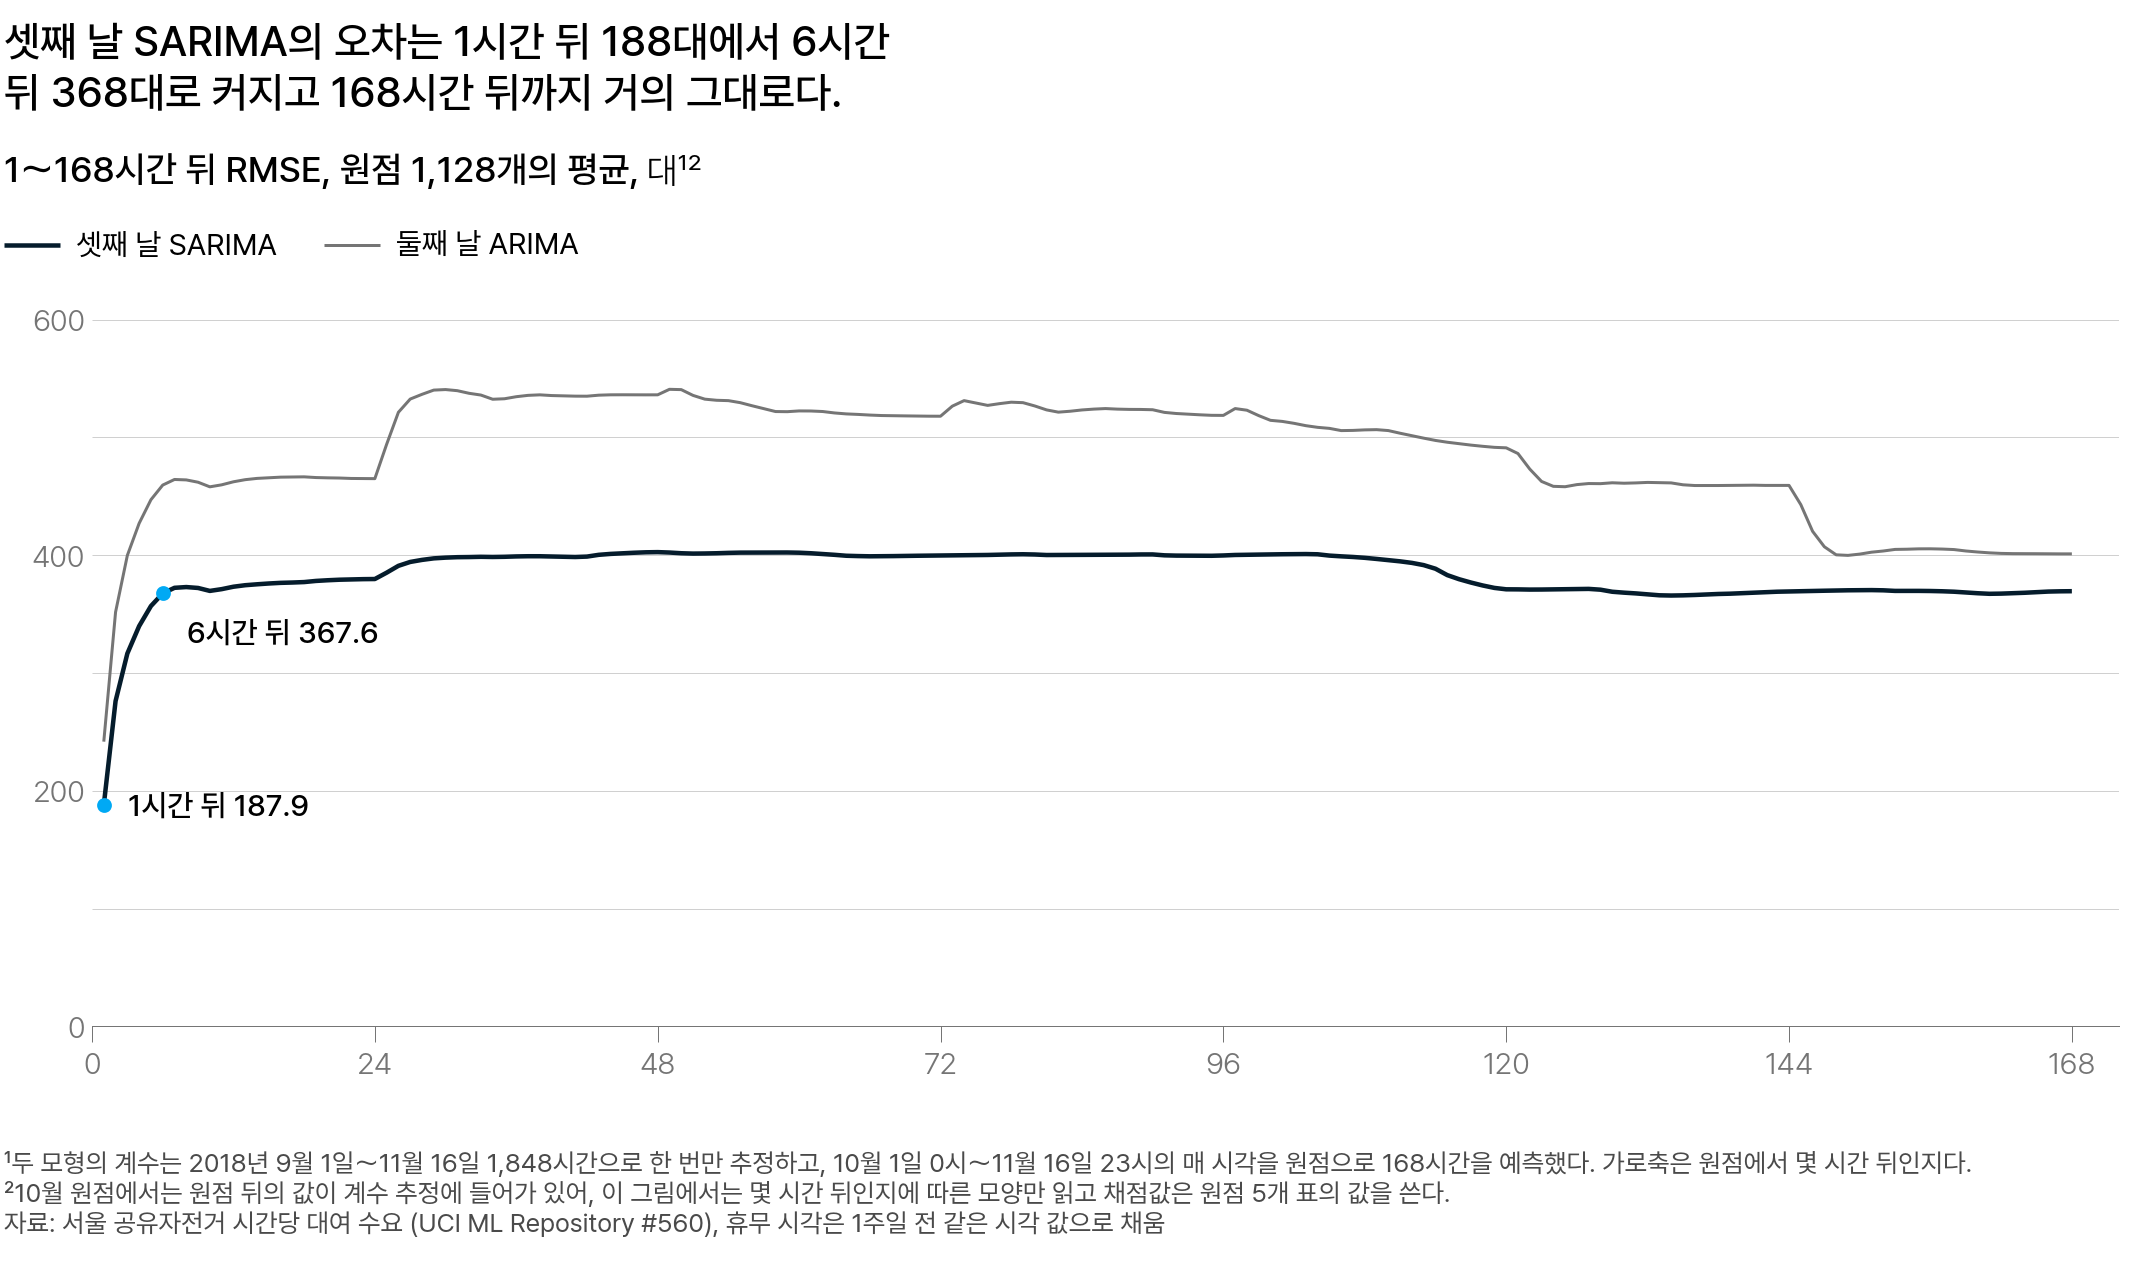

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 원점 1,128개에서 모은 1～168시간 뒤 RMSE. 가로축이 원점에서 몇 시간 뒤인지(1～168), 세로축이 RMSE 다. 남색이 셋째 날 SARIMA, 회색이 둘째 날 ARIMA 이고, 하늘색 점이 셋째 날 SARIMA 의 1시간 뒤와 6시간 뒤다</em></p>

예상 질문의 답은 둘째 보기입니다. 셋째 날 SARIMA 의 RMSE 는 6시간 뒤까지 약 2배로 커진 뒤, 한 시간 더 멀어져도 2% 넘게 변하지 않습니다.

1시간 뒤 예측은 직전 실측을 알고 내서 작게 빗나갑니다. 셋째 날 SARIMA 의 1시간 전 $z$ 계수가 0.78 입니다. 그래서 원점의 $z$ 가 +100대라면 1시간 뒤 예측에는 78대가 남습니다. 이 기여분은 한 시간마다 0.78배로 줄어 6시간 뒤에는 23대만 남습니다($0.78^6 \approx 0.23$). 6시간쯤 지나면 원점의 마지막 실측이 주는 정보가 거의 사라집니다.

그 뒤 예측은 거의 같은 하루 모양을 되풀이해서, 먼 시각이라고 오차가 더 커지지 않습니다.

| 원점에서 몇 시간 뒤 | 셋째 날 SARIMA 의 RMSE(원점 1,128개) |
|---|---:|
| 1시간 뒤 | 187.9대 |
| 6시간 뒤 | 367.6대 |
| 7～168시간 뒤 | 365.8～402.6대 |

그래서 168시간 운영의 오차는 1～168시간 전체로 채점한 값으로 적습니다.

1시간 뒤 RMSE 는 셋째 날 SARIMA 가 187.9대로 둘째 날 ARIMA 의 241.7대보다 작아, AIC 순서와 같습니다. 187.9대만 보면 베이스라인 363.55대보다 훨씬 작아 투입할 것처럼 보입니다. 그러나 168시간을 한 번에 예측하는 같은 조건에서는 원점 5개 평균이 385.06대로 베이스라인보다 큽니다. 그래서 1시간 뒤 RMSE 나 AIC 로 168시간 운영의 투입 여부를 정하지 않습니다.

<details class="lms-extra"><summary>더 깊이 — 먼 시각일수록 오차가 계속 커지는 예</summary>

드리프트 규칙은 첫 값과 마지막 값을 잇는 기울기를 그대로 이어 가는 예측입니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/CV-accuracy-plot-1.png" width="640" height="395"/>
<p align="center"><em>▲ 드리프트 규칙을 구글 종가에 쓴 시계열 교차 검증의 1～8단계 뒤 RMSE. 가로축이 몇 거래일 뒤인지(1～8), 세로축이 RMSE 다. 드리프트 규칙은 먼 시각을 예측할수록 RMSE 가 커진다 (출처: fpp3 §5.10)</em></p>

이런 모형은 1단계 뒤와 먼 시각의 RMSE 차이가 커서, 몇 단계 뒤인지마다 RMSE 를 나눠 적습니다.

</details>

### 재귀 다단계 예측과 직접 다단계 예측

- **재귀 다단계 예측(recursive multi-step forecast)**: 방금 낸 예측을 다음 시각의 입력으로 다시 씁니다. 2시간 뒤를 예측할 때 1시간 뒤의 틀린 값을 입력으로 받으므로, 앞 시각의 오차가 뒤로 이어집니다. 둘째 날 ARIMA 와 셋째 날 SARIMA 가 모형 하나로 이렇게 예측합니다.
- **직접 다단계 예측(direct multi-step forecast)**: 몇 시간 뒤인지마다 모형을 따로 학습합니다. 입력으로는 관측값만 씁니다. 오차는 뒤로 이어지지 않지만 168시간이면 모형이 168개 필요해, 이 모듈은 쓰지 않습니다.

<img src="https://skforecast.org/latest/img/diagram-recursive-mutistep-forecasting.png" width="640" height="314"/>
<p align="center"><em>▲ 재귀 다단계 예측. 방금 만든 예측값(주황)이 다음 스텝에서는 빨간 점선 안의 입력 목록에 들어가 있다 (출처: skforecast, Introduction to forecasting)</em></p>

<img src="https://skforecast.org/latest/img/diagram-direct-multi-step-forecasting.png" width="640" height="305"/>
<p align="center"><em>▲ 직접 다단계 예측. 스텝 +1·+2·+3 마다 별도 모형을 학습하고 입력은 관측값(파랑)만 쓴다. 오차가 뒤로 이어지지 않는 대신 168시간이면 모형이 168개 필요해, 이 모듈은 쓰지 않는다 (출처: skforecast)</em></p>

ARIMA 처럼 식 하나로 다음 시각을 이어 계산하는 모형은 재귀 방식을 씁니다. 직접 다단계 예측은 예측 기간이 몇 스텝으로 짧고 회귀·트리 모형처럼 스텝마다 따로 학습할 수 있을 때 씁니다.

<div class="lms-summary">

**정리**

168시간을 한 번에 예측하는 운영은 1～168시간 뒤를 모두 채점한 값으로 적고, 1시간 뒤 RMSE 로 대신하지 않습니다. 셋째 날 SARIMA 의 1시간 뒤 RMSE 187.9대는 원점 5개 평균 385.06대의 절반보다 작습니다. 6시간 뒤부터는 365.8～402.6대 사이입니다.

**할 일**

- 지표값 옆에 예측 기간 168시간과 예측 원점 시각인 금요일 23시를 적습니다
- $h$ 마다의 RMSE 는 원점 하나가 아니라 여러 원점의 평균으로 봅니다. 여기서는 1,128개입니다

몇 시간 뒤까지만 쓰는 운영이 따로 있으면 1·24·168시간 뒤 RMSE 를 나눠 적습니다.

</div>

> **[문제] 1시간 뒤 지표값을 168시간 뒤 예측의 값으로 적기**
>
> 매 시각 실제값을 받아 한 시각씩만 맞히는 방식으로 RMSE 를 계산하고, 그 숫자를 "채점하는 모형의 168시간 뒤 예측 지표값"으로 보고했다고 해 봅니다. 이 보고가 왜 낙관적인지, 그리고 어떻게 고쳐야 하는지 적어 보세요.

## 7. 여러 예측을 합치는 앙상블

**앙상블은 무엇이고, 언제 도움이 될까요?**

**앙상블(ensemble)** 은 같은 시각에 여러 모형이 낸 예측을 평균하거나 가중치를 곱해 더해 예측 하나로 만드는 방법입니다. 가장 단순한 앙상블은 예측을 모두 더해 개수로 나누는 **단순 평균(simple average)** 입니다.

$$
\underbrace{\hat{y}_t^{\text{앙상블}}}_{\text{합친 예측}} = \frac{1}{M}\sum_{i=1}^{M} \underbrace{\hat{y}_t^{(i)}}_{i \text{번째 모형의 예측}}
$$

- $M$ : 합칠 예측의 개수입니다.

직관적으로 말하면, 한 모형이 모자라게 예측한 시각에 다른 모형이 넘치게 예측하면 평균에서 두 오차가 서로 지워집니다. 이것을 **오차 상쇄**라 부릅니다. 실제 수요가 100대인 시각에 두 예측을 평균하면 이렇습니다.

| 경우 | 모형 A 의 예측 | 모형 B 의 예측 | 예측 2개의 평균 | 평균의 오차 |
|---|---:|---:|---:|---:|
| 오차의 부호가 반대 | 110대 | 90대 | 100대 | 0대 |
| 오차의 부호가 같음 | 110대 | 112대 | 111대 | −11대 |

오차의 부호가 같으면 평균해도 거의 줄지 않습니다.

모형마다 비중을 다르게 주면 **가중 앙상블(weighted ensemble)** 입니다.

$$
\hat{y}_t^{\text{앙상블}} = \sum_{i=1}^{M} w_i \hat{y}_t^{(i)}
$$

- $w_i$ : $i$ 번째 모형에 곱하는 가중치입니다. 합이 1 이고 각각 0 이상입니다.

단순 평균의 예처럼 실제 수요 100대에 모형 A 가 110대, 모형 B 가 90대를 예측했다고 봅니다. 여기에 $w_1 = 0.7$ 과 $w_2 = 0.3$ 을 주면, 110대의 0.7배인 77대와 90대의 0.3배인 27대를 더해 104대입니다.

<img src="https://otexts.com/fpp3/fpp_files/figure-html/combineplot-1.png" width="640" height="395"/>
<p align="center"><em>▲ 호주 외식 지출에 ARIMA(주황)·ETS(초록)·STLF(분홍) 개별 예측 3개와 이들을 합친 앙상블 예측(파랑)을 겹쳐 그린 그림. 검정이 실제값이고, 개별 예측선이 멀어지는 구간에서 파란 앙상블 선은 그 사이에 있다 (출처: fpp3 §13.4)</em></p>

앙상블은 어느 주에나 이기는 후보가 없을 때 씁니다. 예측 원점 5개에서 가장 작은 RMSE 는 계절 나이브 168 이 3번, 셋째 날 SARIMA 가 2번 받았습니다.

## 이득의 크기를 정하는 값: 오차 상관 ρ

**오차 상관(error correlation)** $\rho$ 는 모형 2개의 시각별 오차가 함께 움직이는 정도입니다. $\rho$ 는 「로」라고 읽습니다. $-1$ 이면 완전히 반대, $0$ 이면 무관, $+1$ 이면 완전히 같습니다.

**편향(bias)** 은 오차가 같은 쪽으로 치우친 정도입니다. 부호를 그대로 둔 오차의 평균인 **평균오차(mean error)** 로 재고, 음수면 넘치게 예측한 것입니다.

오차 크기가 같고 편향이 없는 모형 2개를 평균하면, RMSE 가 아래 배율만큼 작아집니다.

$$
\text{배율} = \sqrt{\frac{1+\rho}{2}}
$$

배율은 두 예측을 평균한 RMSE 를 모형 하나의 RMSE 로 나눈 값입니다.

| 오차 상관 $\rho$ | 배율 | RMSE 감소 |
|---:|---:|---:|
| $-0.5$ | 0.50 | 50% |
| $0$ | 0.71 | 29% |
| $+0.5$ | 0.87 | 13% |
| $+0.95$ | 0.99 | 1.3% |

그래서 오차가 함께 움직이지 않는 예측끼리 합쳐야 이득이 큽니다. 상관이 0.95 면 RMSE 감소가 1.3% 로 거의 없습니다. 서울 공유자전거 검증 구간에서 둘째·셋째 날 모형은 오차 상관이 0.76 이라 합쳐도 이득이 작습니다. 계절 나이브 168 과 둘째 날 ARIMA 는 0.20 이라 상관만 보면 이득이 날 조합입니다.

다만 검증 구간에서 이 두 예측은 둘 다 넘치게 예측했습니다. 평균오차가 각각 −136.0대, −166.6대입니다.

반씩 합친 RMSE 208.84대는 계절 나이브 168 하나의 205.25대보다 큽니다. 평균은 오르내림만 줄이고 편향은 남기기 때문입니다. 그래서 합치기 전에 후보마다 평균오차의 부호부터 봅니다. 부호가 같으면 단순 평균으로는 편향이 줄지 않으니, 나은 쪽에 가중치를 더 싣습니다.

### 가중치는 어느 구간에서 고르나

합칠 예측은 계절 나이브 168, 둘째 날 ARIMA, 셋째 날 SARIMA 3개입니다. 베이스라인도 예측을 내는 규칙이라 앙상블 후보로 씁니다. 가중치를 고르는 방법은 **그리드 서치(grid search)** 입니다. 합이 1 인 가중치 조합을 0.1 간격으로 모두 만들어(모형 3개면 66개) 검증 RMSE 가 가장 작은 조합을 고릅니다.

11월 16일 원점의 검증 구간에서는 계절 나이브 168 0.8, 둘째 날 ARIMA 0.2, 셋째 날 SARIMA 0 을 골랐습니다. 검증 RMSE 는 198.26 으로 베이스라인보다 3.4% 작습니다. 순위를 원점 5개로 정한 것처럼 가중치도 원점 여러 개로 고르는 편이 낫지만, 여기서는 방법만 보이려고 한 주로 골랐습니다.

이 값을 앙상블의 지표값으로 적지는 않습니다. 66개 조합 가운데 가장 작은 값이라 실력뿐 아니라 그 주의 우연까지 담겨 있기 때문입니다. 검증 구간에서 고른 설정의 이득이 새 구간에서 줄어드는 이 현상을 **선택 편향(selection bias)** 이라 부릅니다. 그래서 앙상블의 지표값은 가중치를 정한 뒤 테스트 구간을 한 번만 열어 계산합니다. 이 모듈에서 앙상블은 투입 후보가 아니라, 가중치를 고정한 뒤 테스트 구간에서 효과를 확인하는 실험입니다.

<div class="lms-summary">

**정리**

앙상블은 오차가 함께 움직이지 않고 같은 쪽으로 치우치지 않은 예측끼리 합칠 때 이득이 큽니다. 계절 나이브 168 과 둘째 날 ARIMA 는 오차 상관이 0.20 이지만 둘 다 넘치게 빗나갔습니다. 그래서 반씩 합친 RMSE 208.84대가 나은 쪽 하나의 205.25대보다 큽니다.

**할 일**

- 합치기 전에 후보마다 평균오차의 부호를 봅니다
- 가중치(합 1, 0 이상)는 검증 구간에서 0.1 간격 66개 조합으로 고릅니다
- 검증 구간의 최솟값(198.26대)은 선택 편향이 든 값이라 앙상블의 지표값으로 적지 않습니다. 가중치를 고정한 뒤 테스트 구간을 한 번만 열어 효과를 확인합니다

앙상블의 효과는 검증 구간의 최솟값이 아니라 테스트 구간 한 번의 값으로 판단합니다.

</div>

> **[문제] 오차 상관이 $\rho = 0.5$ 인 모형 2개를 평균하면 RMSE가 개별 모형의 절반 아래로 내려간다.**
>
> 1. O (맞다)
> 2. X (틀리다)

## 8. 이 계열의 베이스라인과 오늘의 정리

**후보를 어떤 평가 설계로 채점하고, 평가표에 무엇을 적으며, 언제 투입을 논의할까요?**

후보는 금요일 23시 예측 원점 5개에서 RMSE 로 순위를 정하고, 대수로 적은 오차가 큰지 가늠하려고 MASE 를 함께 적습니다. 지표값을 원점·구간·지표·예측 기간과 함께 적은 표를 **평가표**라 부릅니다.

<div class="lms-summary">

**정리**

둘째 날 ARIMA 와 셋째 날 SARIMA 는 아직 투입하지 않습니다. 예측 원점 5개 평균 RMSE 는 셋째 날 SARIMA 385.06대, 둘째 날 ARIMA 425.68대입니다. 둘 다 베이스라인 계절 나이브 168 의 363.55대보다 큽니다.

**할 일**

- 후보는 예측 원점 5개(10월 19일～11월 16일 금요일 23시)마다 9월 1일부터 원점까지 재적합합니다. 원점 뒤 168시간을 한 번에 예측해 채점합니다
- 평가표에는 후보마다 원점 수·학습 구간·예측 기간·RMSE·MASE(분모 295.40대)를 적습니다

| 예측 | RMSE(대) |
|---|---|
| 계절 나이브 168(베이스라인) | 11월 16일 원점 205.25, 원점 5개 평균 363.55 |
| 셋째 날 SARIMA | 11월 16일 원점 386.08, 원점 5개 평균 385.06 |
| 계절 나이브 24 | 11월 16일 원점 271.23, 원점 5개 평균 406.05 |
| 둘째 날 ARIMA | 11월 16일 원점 271.22, 원점 5개 평균 425.68 |

원점 5개 평균 RMSE 가 363.55대보다 작은 후보만 투입을 논의하고, 테스트 구간은 그 뒤 한 번만 엽니다.

</div>

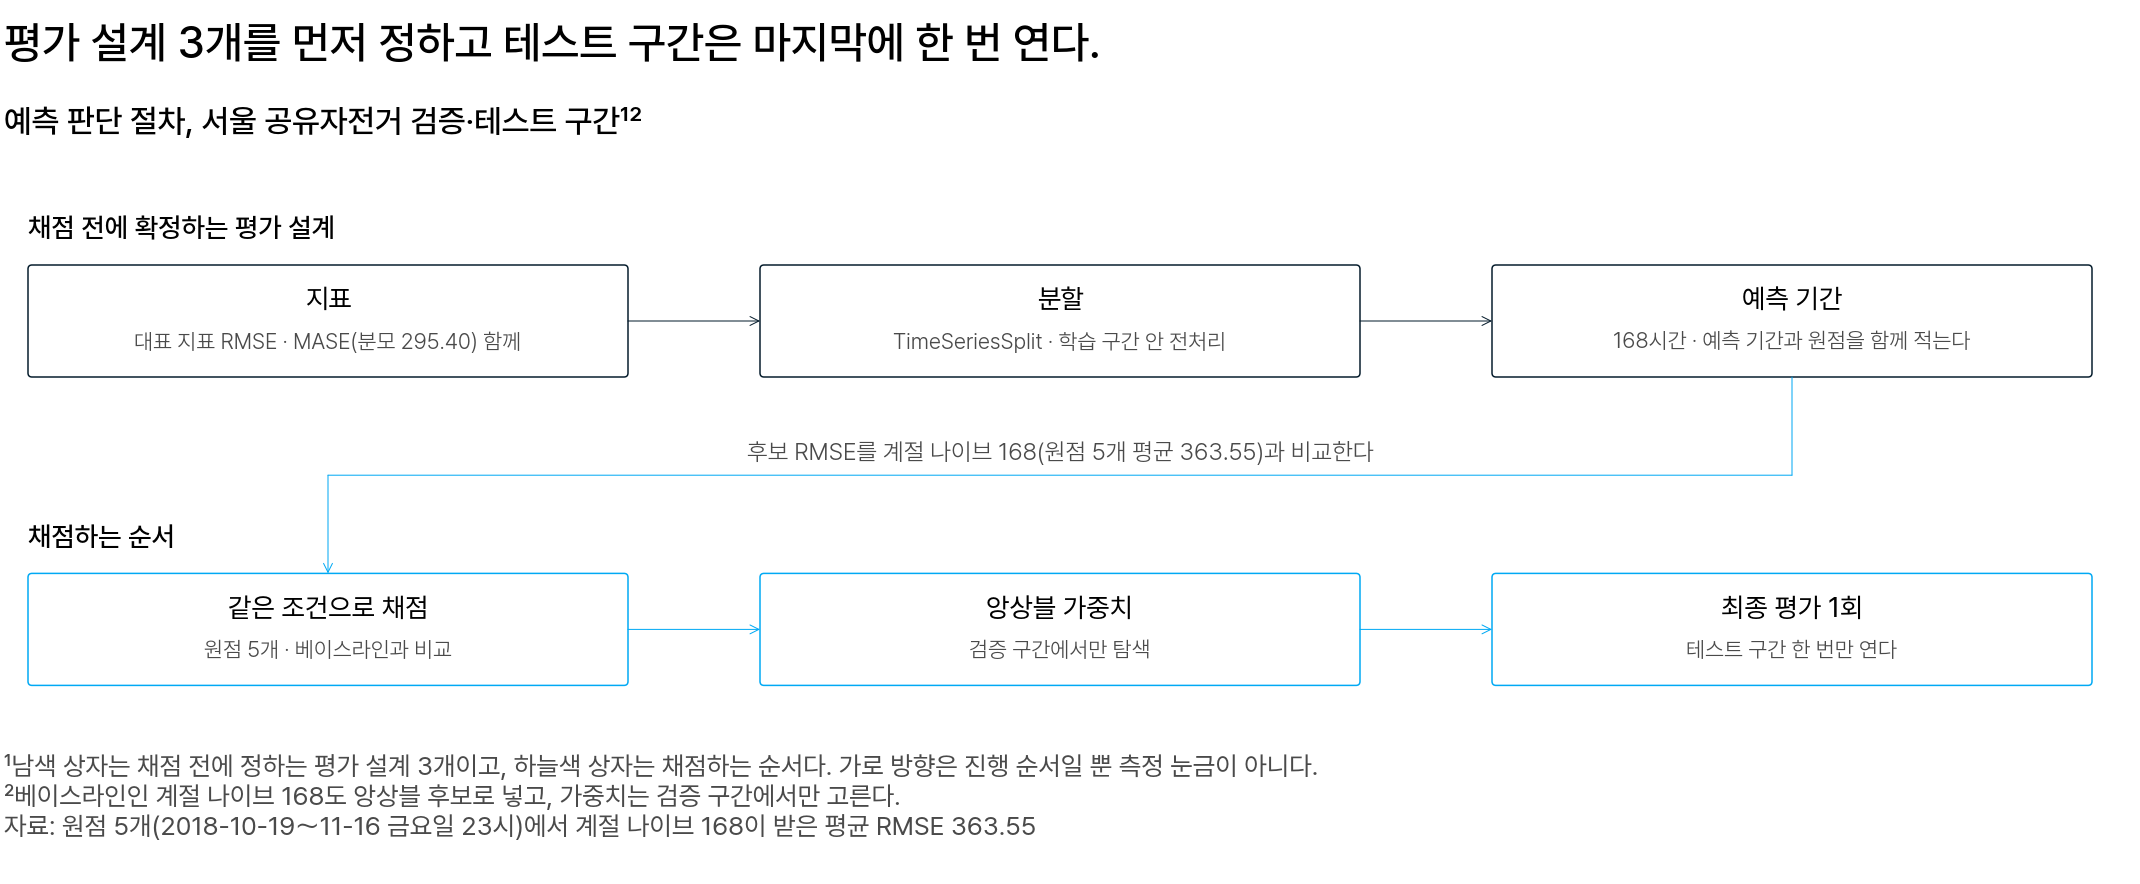

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 평가 설계와 채점 순서. 위쪽 상자 3개(남색 테두리)는 채점 전에 정하는 평가 설계인 지표·분할·예측 기간이고, 아래쪽 상자 3개(하늘색 테두리)는 채점하는 순서다</em></p>

## 수업에서 다룰 질문

읽기는 여기까지이고, **아래 질문은 수업에서 팀으로 마칩니다.** 지금 해설이 열리지 않아도 미완결이 아닙니다.

각자 답과 확신도(1～5)를 적어 잠그면 팀의 답 분포가 공개됩니다. 근거 3문장을 교환해 토론한 뒤 팀이 답 하나로 모여 제출합니다.

> **[문제] 팀 라운드: 가중치 0을 받은 모형을 파이프라인에서 뺄 것인가**
>
> 오늘 오후 실습에서 실제로 이 결과가 나옵니다. 앙상블에 넣을 후보는 계절 나이브 168, 둘째 날 ARIMA, 셋째 날 SARIMA 3개입니다. 11월 16일 원점의 검증 168시간에서 후보 3개의 가중치를 0.1 간격 그리드 서치로 골랐더니, 검증 RMSE 가 가장 낮은 조합(198.26대)에서 셋째 날 SARIMA 의 가중치가 0 이었습니다. 하루 전 같은 시각의 값과 오차를 보는 항 두 개를 더한 그 모형입니다. 원점 5개 평균 RMSE 가 385.06대로, 둘째 날 ARIMA 의 425.68대보다 작았던 모형입니다.
> 
> 앙상블 자체가 효과가 있는지는 오늘 오후 과제에서 가중치를 고정한 채 테스트 168시간을 한 번만 열어 직접 확인합니다. 그러니 오늘 물을 것은 「후보 3개를 앙상블로 합칠 것인가」가 아니라 「앙상블 파이프라인에 셋째 날 SARIMA 를 남길 것인가」입니다.
> 
> 운영 파이프라인을 확정해야 하는데, 팀 안에서 의견이 3가지로 나뉘었습니다.
> 
> - **관점 A: 뺀다.** 가중치 0은 "이 모형이 기여하지 않는다"는 데이터의 결론이다. 매주 SARIMA 를 다시 적합해 168시간 뒤를 내다보는 계산과 실패 위험을 그대로 안고 갈 이유가 없다. 파이프라인은 단순할수록 사고가 적다.
> - **관점 B: 둔다.** 가중치 0은 그 검증 7일에서 나온 결과일 뿐이다. 그리드 서치는 시각 168개로 가중치 3개를 고른 것이라 값이 크게 달라질 수 있고, 계절이 바뀌거나 이상 기후가 오면 SARIMA 의 가중치가 다시 0 보다 커질 수 있다. 낮은 가중치로라도 남겨 두면 그때 대비가 된다.
> - **관점 C: 다른 원점에서도 0인지 재 본 뒤에 정한다.** 지금 있는 0은 11월 16일 원점 하나의 검증 구간에서 나온 값이다. 오늘 쓴 원점 5개마다 같은 그리드 서치를 실행해, 대부분의 원점에서 0이면 뺀다. 결정을 미루자는 것이 아니라 뺄 조건을 지금 문장으로 확정하자는 것이다.
> 
> 자기 입장 하나와 근거 3문장, 그리고 확신도를 정해 오세요.